# Customer Churn Prediction and Retention Analytics

## 1. Business Problem

Customer churn occurs when a customer stops using a company's products or services.

For a telecom company, customer churn can lead to loss of recurring revenue and increased customer acquisition costs. Therefore, businesses want to identify customers who are likely to churn so that proactive retention strategies can be applied.

## 2. Project Objective

The objectives of this project are to:

- Understand customer characteristics and behavior.
- Identify factors associated with customer churn.
- Build machine learning models to predict customer churn.
- Evaluate and compare classification models.
- Explain model predictions using Explainable AI techniques.
- Identify high-risk customer segments.
- Estimate potential revenue at risk.
- Provide data-driven customer retention insights.

## 3. Dataset

**Dataset:** IBM Telco Customer Churn Dataset

The dataset contains information about telecom customers, including demographic information, services subscribed, contract details, billing information, customer lifetime value, and churn-related information.

## 4. Machine Learning Problem

This is a **Supervised Machine Learning** problem because the historical dataset contains customer information along with a known outcome indicating whether the customer churned.

The prediction task is formulated as a **Binary Classification** problem:

- `0` = Customer did not churn
- `1` = Customer churned

# 2. Import Required Libraries

Before working with the dataset, we import the Python libraries required for data manipulation, numerical analysis, and data visualization.

Each library has a specific role in the data science workflow.

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing DataFrames
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# 3. Load the Dataset

The dataset is stored in Excel format, so we use Pandas' `read_excel()` function to load it into a DataFrame.

After loading the dataset, we will check its dimensions to verify that the data has been imported correctly.

In [3]:
# Load the dataset
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

# Display basic information about the dataset size
print("Dataset loaded successfully!")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Dataset loaded successfully!
Number of rows    : 7043
Number of columns : 33


# 4. Preview the Dataset

After loading the dataset, we inspect the first few records to understand the structure of the data and verify that the values have been loaded correctly.

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# 5. Understand Dataset Structure

Before cleaning the dataset, we need to understand the structure of each column.

We will examine:

- Column names
- Number of non-null values
- Data types
- Memory usage

This helps us identify numerical and categorical variables and detect potential missing values or data-quality issues.

In [5]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# 6. Review All Column Names

The dataset contains 33 columns. We will display all column names so that we can review every variable before beginning data cleaning and exploratory analysis.

In [6]:
# Display all column names
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

 1. CustomerID
 2. Count
 3. Country
 4. State
 5. City
 6. Zip Code
 7. Lat Long
 8. Latitude
 9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


# 7. Check for Missing Values

Missing values can affect data analysis and machine learning models.

We will calculate the number and percentage of missing values in each column.

This allows us to distinguish between:

- Columns with no missing values.
- Columns with a small number of missing values.
- Columns with substantial missing values.
- Missing values that may have a meaningful business interpretation.

In [7]:
# Calculate missing values
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

# Show only columns that contain missing values
missing_values[missing_values["Missing Count"] > 0].sort_values(
    by="Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage
Churn Reason,5174,73.463013


# 8. Check for Duplicate Customers

Each customer should have a unique `CustomerID`.

We will check whether any customer IDs appear more than once. Duplicate customer records can distort exploratory analysis and machine learning results if they are unintentionally counted multiple times.

In [8]:
# Check for duplicate Customer IDs
duplicate_customer_ids = df["CustomerID"].duplicated().sum()

print(f"Duplicate Customer IDs: {duplicate_customer_ids}")

Duplicate Customer IDs: 0


# 9. Check for Constant Columns

A constant column contains the same value for every observation.

Such a column provides no useful information for a machine learning model because it cannot distinguish one customer from another.

We will identify columns that contain only one unique value.

In [9]:
# Count the number of unique values in each column
unique_counts = df.nunique()

# Display columns containing only one unique value
constant_columns = unique_counts[unique_counts == 1]

print("Constant columns:")
print(constant_columns)

Constant columns:
Count      1
Country    1
State      1
dtype: int64


# 10. Explore Numerical Variables

Descriptive statistics help us understand the distribution and range of numerical variables.

We will examine measures such as:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

This helps identify unusual values, potential data-quality problems, and differences in scale between numerical variables.

In [10]:
# Generate descriptive statistics for numerical columns
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


# 11. Analyze Target Variable Distribution

The target variable for this project is `Churn Value`.

It is a binary variable:

- `0` = Customer did not churn
- `1` = Customer churned

We will calculate the number and percentage of customers in each class to understand the class distribution before building machine learning models.

In [11]:
# Calculate churn counts
churn_counts = df["Churn Value"].value_counts().sort_index()

# Calculate churn percentages
churn_percentages = df["Churn Value"].value_counts(
    normalize=True
).sort_index() * 100

# Combine counts and percentages
churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percentages
})

churn_summary

,Customer Count,Percentage
Churn Value,,
0,5174,73.463013
1,1869,26.536987


# 12. Explore Categorical Variables

Many features in the dataset are categorical variables.

Before preprocessing them for machine learning, we need to understand the unique categories present in each column.

This helps us identify:

- The number of categories.
- Possible unexpected values.
- Binary versus multi-category variables.
- Categories that may require special handling during preprocessing.

In [12]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
for column in categorical_columns:
    print(f"- {column}")

Categorical columns:
- CustomerID
- Country
- State
- City
- Lat Long
- Gender
- Senior Citizen
- Partner
- Dependents
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Total Charges
- Churn Label
- Churn Reason


# 13. Investigate the `Total Charges` Column

`Total Charges` represents the total amount charged to a customer and would normally be expected to contain numerical values.

However, Pandas has identified this column as an `object` type.

We will inspect its unique values and data types to determine why it was interpreted as text before deciding how to clean it.

In [13]:
# Inspect the Total Charges column
print("Data type:")
print(df["Total Charges"].dtype)

print("\nSample values:")
print(df["Total Charges"].head(20).to_string(index=False))

Data type:
object

Sample values:
  108.15
  151.65
   820.5
 3046.05
  5036.3
  528.35
   39.65
   20.15
 4749.15
    30.2
  1093.1
   316.9
 3549.25
  1105.4
  144.15
  1426.4
   633.3
 1752.55
  857.25
   79.35


## 13.1 Identify Non-Numeric Values

Although `Total Charges` contains values that look numeric, the column has been loaded as text.

We will identify values that cannot be converted to numbers. This helps us determine whether there are blank strings, spaces, or other unexpected values that caused Pandas to assign the `object` data type.

In [14]:
# Try converting Total Charges to numeric values
total_charges_numeric = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

# Find values that could not be converted to numbers
non_numeric_values = df.loc[
    total_charges_numeric.isna(),
    "Total Charges"
]

print("Number of non-numeric values:", len(non_numeric_values))
print("\nNon-numeric values:")
print(non_numeric_values.value_counts(dropna=False))

Number of non-numeric values: 11

Non-numeric values:
Total Charges
    11
Name: count, dtype: int64


## 13.2 Investigate Non-Numeric `Total Charges` Records

The `Total Charges` column contains 11 values that cannot be interpreted as numeric values.

Before cleaning them, we will inspect the corresponding customer records, particularly their tenure and churn status.

This helps us determine whether the missing values are genuine data-quality issues or represent a meaningful business situation.

In [15]:
# Display the records where Total Charges could not be converted to numeric
problem_rows = df.loc[
    total_charges_numeric.isna(),
    ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label", "Churn Value"]
]

problem_rows

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label,Churn Value
2234,4472-LVYGI,0,52.55,,No,0
2438,3115-CZMZD,0,20.25,,No,0
2568,5709-LVOEQ,0,80.85,,No,0
2667,4367-NUYAO,0,25.75,,No,0
2856,1371-DWPAZ,0,56.05,,No,0
4331,7644-OMVMY,0,19.85,,No,0
4687,3213-VVOLG,0,25.35,,No,0
5104,2520-SGTTA,0,20.00,,No,0
5719,2923-ARZLG,0,19.70,,No,0
6772,4075-WKNIU,0,73.35,,No,0


## 13.3 Clean `Total Charges`

The investigation showed that all 11 non-numeric `Total Charges` values belong to customers with zero months of tenure.

These customers have not accumulated tenure-based charges in the dataset, so we will represent their `Total Charges` as `0`.

After replacing the blank values, the column will be converted to a numerical data type for analysis and machine learning.

In [16]:
# Convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

# Replace missing Total Charges for zero-tenure customers with 0
df.loc[
    (df["Total Charges"].isna()) &
    (df["Tenure Months"] == 0),
    "Total Charges"
] = 0

# Confirm the data type and remaining missing values
print("Data type:", df["Total Charges"].dtype)
print("Remaining missing values:", df["Total Charges"].isna().sum())

Data type: float64
Remaining missing values: 0


# 14. Validate Numerical Feature Ranges

Before continuing with exploratory analysis, we will perform basic validity checks on important numerical variables.

We will check whether:

- `Tenure Months` is within the expected range.
- `Monthly Charges` contains valid positive values.
- `Total Charges` contains non-negative values.
- `Churn Value` contains only binary values.
- `Churn Score` is within its expected score range.
- `CLTV` contains positive values.

Range checks help identify potential data-quality problems before modeling.

In [17]:
# Check the ranges of important numerical variables

print("Tenure Months:")
print("Minimum:", df["Tenure Months"].min())
print("Maximum:", df["Tenure Months"].max())

print("\nMonthly Charges:")
print("Minimum:", df["Monthly Charges"].min())
print("Maximum:", df["Monthly Charges"].max())

print("\nTotal Charges:")
print("Minimum:", df["Total Charges"].min())
print("Maximum:", df["Total Charges"].max())

print("\nChurn Value:")
print("Unique values:", sorted(df["Churn Value"].unique()))

print("\nChurn Score:")
print("Minimum:", df["Churn Score"].min())
print("Maximum:", df["Churn Score"].max())

print("\nCLTV:")
print("Minimum:", df["CLTV"].min())
print("Maximum:", df["CLTV"].max())

Tenure Months:
Minimum: 0
Maximum: 72

Monthly Charges:
Minimum: 18.25
Maximum: 118.75

Total Charges:
Minimum: 0.0
Maximum: 8684.8

Churn Value:
Unique values: [np.int64(0), np.int64(1)]

Churn Score:
Minimum: 5
Maximum: 100

CLTV:
Minimum: 2003
Maximum: 6500


# 15. Explore Categorical Feature Values

Categorical variables contain a finite set of possible values.

We will inspect the unique values and their frequencies for each categorical feature.

This helps us understand the structure of the categorical data and identify categories that may require special treatment during preprocessing.

In [18]:
# Inspect unique values and their frequencies
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

for column in categorical_features:
    print(f"\n{'=' * 50}")
    print(column)
    print(f"{'=' * 50}")
    print(df[column].value_counts())


Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Multiple Lines
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Internet Service
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Online Security
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Online Backup
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Device Protection
Device Protection
No                     3095
Yes                    2422
N

# 16. Check for Duplicate Rows

Duplicate rows can cause certain customers or observations to be counted more than once.

We will check whether the dataset contains completely duplicated records across all columns.

In [19]:
# Count completely duplicated rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


# 17. Data Understanding Summary

After inspecting the dataset, we identified the following characteristics and data-quality considerations.

## Dataset Overview

- The dataset contains customer-level telecom information.
- Each row represents one customer.
- `CustomerID` uniquely identifies each customer.
- The target variable is `Churn Value`.
- The dataset contains both numerical and categorical features.

## Data Quality Findings

- No duplicate customer IDs were found.
- No completely duplicated rows were found.
- `Total Charges` was initially stored as text and was converted to numeric.
- 11 blank `Total Charges` values were associated with customers having zero months of tenure and were represented as `0`.
- `Churn Reason` contains missing values for customers who did not churn. This missingness has a business meaning rather than representing a conventional data-entry error.
- `Count`, `Country`, and `State` are constant columns and do not provide useful predictive information.

## Target Variable

`Churn Value` is a binary classification target:

- `0` = Customer did not churn
- `1` = Customer churned

Approximately 26.5% of customers in the dataset churned, indicating that the target classes are imbalanced.

## Variables Requiring Special Treatment

The following variables will not be used as predictive features:

- `CustomerID` — identifier only.
- `Count` — constant/reporting field.
- `Country` — constant.
- `State` — constant.
- `Churn Label` — duplicate representation of the target.
- `Churn Reason` — information available after or as a consequence of churn.
- `Churn Score` — an existing churn-related score and therefore not appropriate as an input to our independent churn prediction model.

`CLTV` will be retained for further investigation because it may provide useful customer-value information. Its suitability as a predictive feature will be considered carefully during feature engineering.

## Next Step

The next stage is **Exploratory Data Analysis (EDA)**.

During EDA, we will investigate relationships between customer characteristics and churn to identify patterns that may be useful for machine learning and customer retention strategies.

# 18. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and visualizing data to discover patterns, relationships, distributions, and potential anomalies.

In this project, EDA will help us understand:

- How churn is distributed across customers.
- Which customer characteristics are associated with churn.
- How numerical variables differ between churned and retained customers.
- Which customer segments may have higher churn risk.

We will begin by visualizing the overall distribution of the target variable.

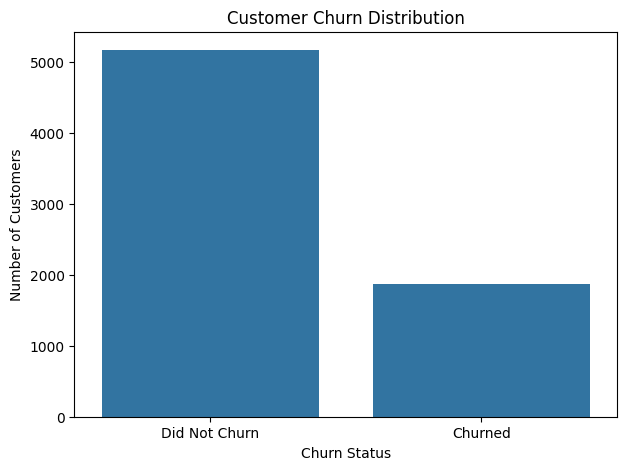

In [20]:
# Visualize the distribution of the target variable

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn Value"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["Did Not Churn", "Churned"]
)

plt.show()

# 19. Churn Rate by Contract Type

Contract type is an important business feature because customers may have different levels of commitment depending on whether they use a month-to-month, one-year, or two-year contract.

We will calculate the churn rate for each contract type.

Churn rate is more informative than simply counting churned customers because it accounts for the different number of customers in each contract group.

In [21]:
# Calculate churn rate by contract type

contract_churn = (
    df.groupby("Contract")["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Convert churn rate from proportion to percentage
contract_churn["Churn Rate (%)"] = contract_churn["mean"] * 100

# Rename columns for clarity
contract_churn = contract_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers"
})

# Keep the relevant columns
contract_churn = contract_churn[
    ["Contract", "Total Customers", "Churned Customers", "Churn Rate (%)"]
]

contract_churn

,Contract,Total Customers,Churned Customers,Churn Rate (%)
0,Month-to-month,3875,1655,42.709677
1,One year,1473,166,11.269518
2,Two year,1695,48,2.831858


# 20. Visualize Churn Rate by Contract Type

The previous analysis showed substantial differences in churn rate across contract types.

We will visualize these differences using a bar chart so that the relative churn rates can be compared more easily.

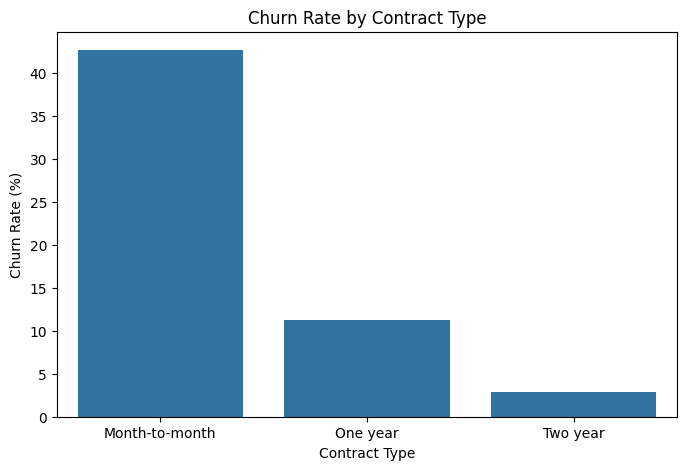

In [22]:
# Visualize churn rate by contract type

plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

# 21. Churn Rate by Internet Service

Internet service type may be associated with customer churn because customers using different services may have different experiences, pricing, service requirements, and expectations.

We will calculate the churn rate for each internet service category.

As with contract analysis, we will compare churn rates rather than raw churn counts so that the different group sizes are taken into account.

In [23]:
# Calculate churn rate by internet service

internet_churn = (
    df.groupby("Internet Service")["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Convert churn proportion to percentage
internet_churn["Churn Rate (%)"] = internet_churn["mean"] * 100

# Rename columns
internet_churn = internet_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers"
})

# Keep relevant columns
internet_churn = internet_churn[
    ["Internet Service", "Total Customers", "Churned Customers", "Churn Rate (%)"]
]

internet_churn

,Internet Service,Total Customers,Churned Customers,Churn Rate (%)
0,DSL,2421,459,18.959108
1,Fiber optic,3096,1297,41.892765
2,No,1526,113,7.404980


# 22. Visualize Churn Rate by Internet Service

The previous analysis showed differences in churn rates across internet service categories.

We will visualize these differences using a bar chart to make the comparison easier to interpret.

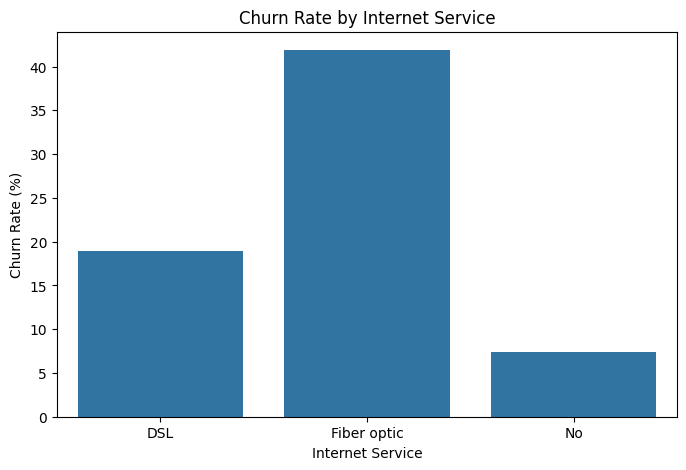

In [24]:
# Visualize churn rate by internet service

plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="Internet Service",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

# 23. Churn Rate by Contract and Internet Service

Individual feature analysis can sometimes hide relationships between variables.

For example, the higher churn rate observed among fiber optic customers may be related to differences in contract types within that customer group.

To investigate this, we will calculate churn rates across combinations of:

- Contract type
- Internet service

This allows us to examine whether the relationship between internet service and churn changes across different contract types.

In [25]:
# Calculate churn rate by contract and internet service

contract_internet_churn = (
    df.groupby(["Contract", "Internet Service"])["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Convert churn proportion to percentage
contract_internet_churn["Churn Rate (%)"] = (
    contract_internet_churn["mean"] * 100
)

# Rename columns
contract_internet_churn = contract_internet_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers"
})

# Keep relevant columns
contract_internet_churn = contract_internet_churn[
    [
        "Contract",
        "Internet Service",
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)"
    ]
]

contract_internet_churn

,Contract,Internet Service,Total Customers,Churned Customers,Churn Rate (%)
0,Month-to-month,DSL,1223,394,32.215863
1,Month-to-month,Fiber optic,2128,1162,54.605263
2,Month-to-month,No,524,99,18.893130
3,One year,DSL,570,53,9.298246
4,One year,Fiber optic,539,104,19.294991
5,One year,No,364,9,2.472527
6,Two year,DSL,628,12,1.910828
7,Two year,Fiber optic,429,31,7.226107
8,Two year,No,638,5,0.783699


# 24. Visualize Churn Rate by Contract and Internet Service

The segment analysis showed that churn rates vary across both contract type and internet service.

We will use a grouped bar chart to visualize these relationships simultaneously.

This allows us to compare internet service categories within each contract type and identify potential interaction patterns.

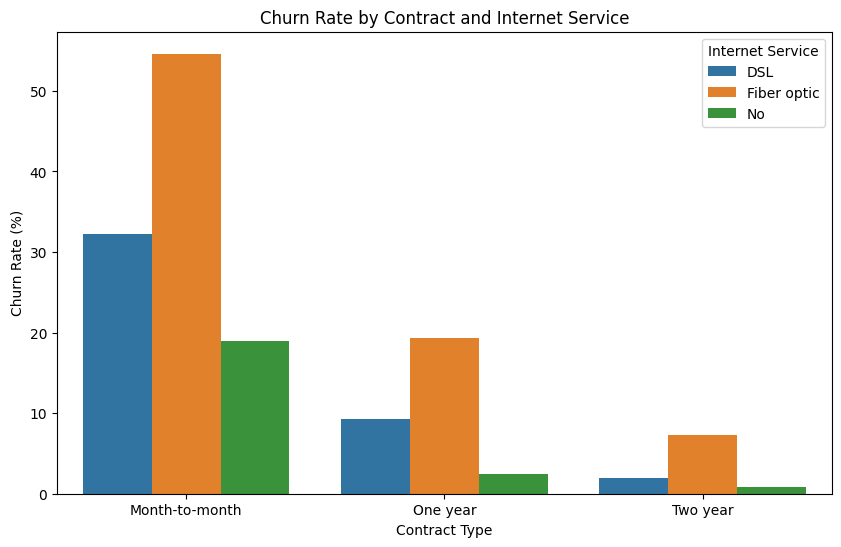

In [26]:
# Visualize churn rate by contract and internet service

plt.figure(figsize=(10, 6))

sns.barplot(
    data=contract_internet_churn,
    x="Contract",
    y="Churn Rate (%)",
    hue="Internet Service"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Internet Service")

plt.show()

# 25. Analyze Customer Tenure and Churn

`Tenure Months` represents the number of months a customer has been with the company.

Customer tenure is an important numerical feature because customers at different stages of their relationship with the company may have different churn behavior.

We will compare the distribution of tenure between customers who churned and customers who did not churn.

In [27]:
# Calculate average and median tenure by churn status

tenure_churn_summary = (
    df.groupby("Churn Value")["Tenure Months"]
      .agg(["count", "mean", "median", "min", "max"])
      .reset_index()
)

# Replace binary values with readable labels
tenure_churn_summary["Churn Status"] = tenure_churn_summary["Churn Value"].map({
    0: "Did Not Churn",
    1: "Churned"
})

# Reorder columns
tenure_churn_summary = tenure_churn_summary[
    ["Churn Status", "count", "mean", "median", "min", "max"]
]

tenure_churn_summary

,Churn Status,count,mean,median,min,max
0,Did Not Churn,5174,37.569965,38.0,0,72
1,Churned,1869,17.979133,10.0,1,72


# 26. Visualize Tenure Distribution by Churn Status

The summary statistics showed that churned customers have lower average and median tenure than customers who did not churn.

We will use a box plot to compare the distribution of `Tenure Months` across the two churn groups.

A box plot allows us to compare the median, spread, and potential outliers of a numerical variable between groups.

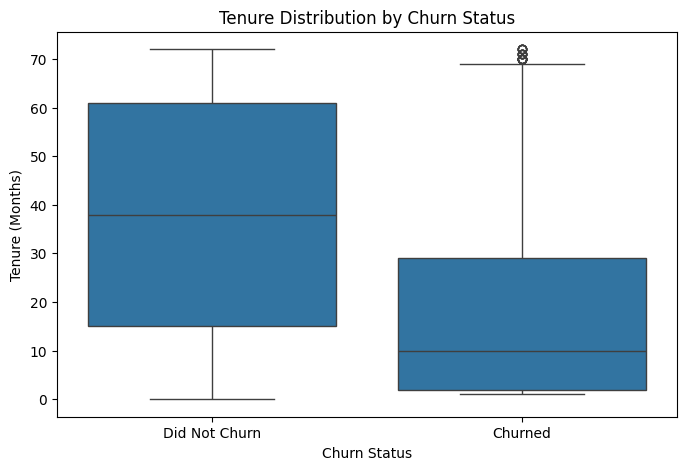

In [28]:
# Create a box plot of tenure by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.xticks(
    [0, 1],
    ["Did Not Churn", "Churned"]
)

plt.show()

# 27. Analyze Monthly Charges and Churn

`Monthly Charges` represents the recurring monthly amount charged to each customer.

Pricing and recurring costs may be associated with customer churn, so we will compare monthly charges between customers who churned and customers who did not churn.

We will examine the count, mean, median, minimum, and maximum values for each churn group.

In [29]:
# Calculate monthly charge statistics by churn status

monthly_charges_churn_summary = (
    df.groupby("Churn Value")["Monthly Charges"]
      .agg(["count", "mean", "median", "min", "max"])
      .reset_index()
)

# Replace binary values with readable labels
monthly_charges_churn_summary["Churn Status"] = (
    monthly_charges_churn_summary["Churn Value"].map({
        0: "Did Not Churn",
        1: "Churned"
    })
)

# Reorder columns
monthly_charges_churn_summary = monthly_charges_churn_summary[
    ["Churn Status", "count", "mean", "median", "min", "max"]
]

monthly_charges_churn_summary

,Churn Status,count,mean,median,min,max
0,Did Not Churn,5174,61.265124,64.425,18.25,118.75
1,Churned,1869,74.441332,79.650,18.85,118.35


# 28. Visualize Monthly Charges by Churn Status

The descriptive statistics showed that churned customers have higher average and median monthly charges than customers who did not churn.

We will use a box plot to compare the distribution of `Monthly Charges` across the two churn groups.

This allows us to examine the median, spread, and potential outliers in monthly charges.

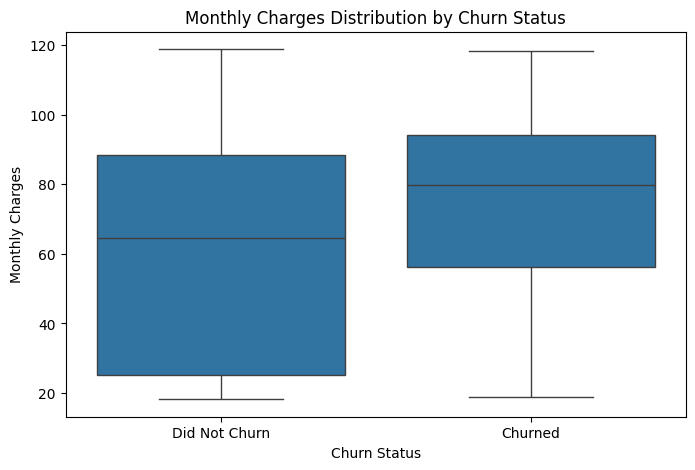

In [30]:
# Create a box plot of monthly charges by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Monthly Charges"
)

plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.xticks(
    [0, 1],
    ["Did Not Churn", "Churned"]
)

plt.show()

# 29. Analyze Total Charges and Churn

`Total Charges` represents the total amount charged to a customer over their tenure with the company.

Because total charges are influenced by both the customer's monthly charges and how long they have been a customer, this feature may provide additional information about customer behavior.

We will compare total charges between customers who churned and customers who did not churn.

In [31]:
# Calculate total charges statistics by churn status

total_charges_churn_summary = (
    df.groupby("Churn Value")["Total Charges"]
      .agg(["count", "mean", "median", "min", "max"])
      .reset_index()
)

# Replace binary values with readable labels
total_charges_churn_summary["Churn Status"] = (
    total_charges_churn_summary["Churn Value"].map({
        0: "Did Not Churn",
        1: "Churned"
    })
)

# Reorder columns
total_charges_churn_summary = total_charges_churn_summary[
    ["Churn Status", "count", "mean", "median", "min", "max"]
]

total_charges_churn_summary

,Churn Status,count,mean,median,min,max
0,Did Not Churn,5174,2549.911442,1679.525,0.00,8672.45
1,Churned,1869,1531.796094,703.550,18.85,8684.80


# 30. Visualize Total Charges by Churn Status

The descriptive statistics showed that churned customers have lower average and median total charges than customers who did not churn.

Because total charges are cumulative and closely related to tenure, we will visualize their distributions to better understand the difference between the two churn groups.

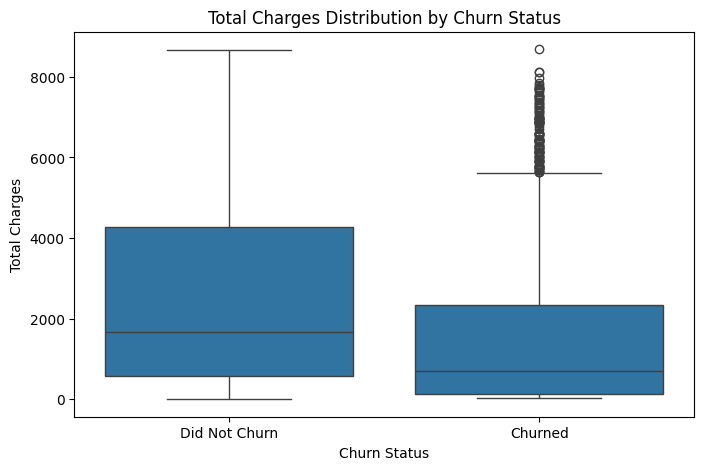

In [32]:
# Create a box plot of total charges by churn status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Value",
    y="Total Charges"
)

plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Charges")

plt.xticks(
    [0, 1],
    ["Did Not Churn", "Churned"]
)

plt.show()

# 31. Churn Rate by Payment Method

Payment method represents how customers pay for their telecom services.

Different payment methods may be associated with different customer behaviors or customer segments.

We will calculate the churn rate for each payment method to determine whether churn patterns differ across these groups.

In [33]:
# Calculate churn rate by payment method

payment_churn = (
    df.groupby("Payment Method")["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Convert churn proportion to percentage
payment_churn["Churn Rate (%)"] = payment_churn["mean"] * 100

# Rename columns
payment_churn = payment_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers"
})

# Keep relevant columns
payment_churn = payment_churn[
    [
        "Payment Method",
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)"
    ]
]

payment_churn

,Payment Method,Total Customers,Churned Customers,Churn Rate (%)
0,Bank transfer (automatic),1544,258,16.709845
1,Credit card (automatic),1522,232,15.243101
2,Electronic check,2365,1071,45.285412
3,Mailed check,1612,308,19.106700


# 32. Visualize Churn Rate by Payment Method

The previous analysis showed differences in churn rates across payment methods.

We will visualize these differences using a bar chart to make the comparison easier to interpret.

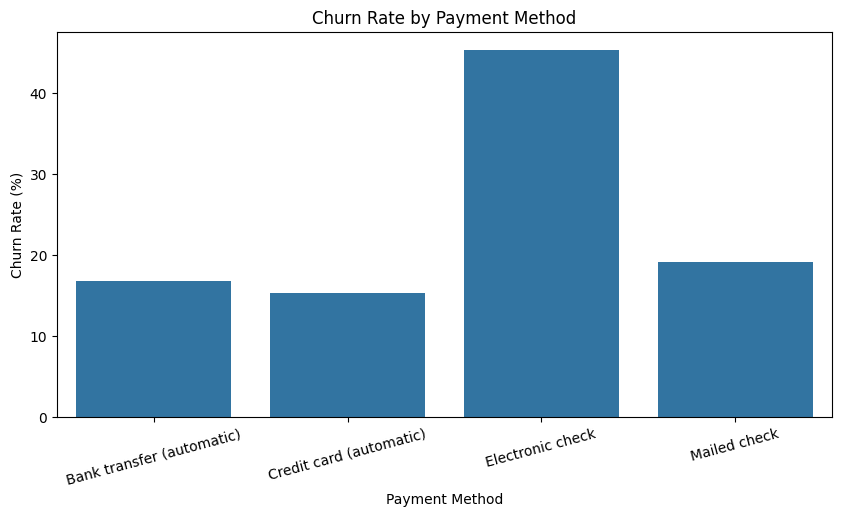

In [34]:
# Visualize churn rate by payment method

plt.figure(figsize=(10, 5))

sns.barplot(
    data=payment_churn,
    x="Payment Method",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

# 33. Churn Rate by Customer Profile

Customer demographic and household characteristics may be associated with different churn patterns.

We will analyze the following variables:

- `Senior Citizen`
- `Partner`
- `Dependents`

For each variable, we will calculate the number of customers, number of churned customers, and churn rate within each category.

Using the same calculation pattern across multiple variables makes the analysis consistent and reusable.

In [35]:
# Customer profile features to analyze
profile_features = [
    "Senior Citizen",
    "Partner",
    "Dependents"
]

# Calculate churn statistics for each profile feature
profile_churn_results = []

for feature in profile_features:
    summary = (
        df.groupby(feature)["Churn Value"]
          .agg(["count", "sum", "mean"])
          .reset_index()
    )
    
    summary["Churn Rate (%)"] = summary["mean"] * 100
    
    summary = summary.rename(columns={
        "count": "Total Customers",
        "sum": "Churned Customers"
    })
    
    summary["Feature"] = feature
    
    profile_churn_results.append(summary)

# Combine all results
profile_churn = pd.concat(
    profile_churn_results,
    ignore_index=True
)

# Display the results
profile_churn

,Senior Citizen,Total Customers,Churned Customers,mean,Churn Rate (%),Feature,Partner,Dependents
0,No,5901,1393,0.236062,23.606168,Senior Citizen,NaN,NaN
1,Yes,1142,476,0.416813,41.681261,Senior Citizen,NaN,NaN
2,NaN,3641,1200,0.329580,32.957979,Partner,No,NaN
3,NaN,3402,669,0.196649,19.664903,Partner,Yes,NaN
4,NaN,5416,1763,0.325517,32.551699,Dependents,NaN,No
5,NaN,1627,106,0.065151,6.515058,Dependents,NaN,Yes


# 34. Prepare Customer Profile Churn Results

The previous analysis calculated churn statistics for Senior Citizen, Partner, and Dependents.

The combined result contains the original feature columns from each separate analysis, which creates unnecessary `NaN` values.

We will reshape the results into a cleaner structure containing:

- Feature
- Category
- Total Customers
- Churned Customers
- Churn Rate

This structure will make the results easier to visualize and interpret.

In [36]:
# Customer profile features to analyze
profile_features = [
    "Senior Citizen",
    "Partner",
    "Dependents"
]

# Store results
profile_churn_results = []

for feature in profile_features:
    
    summary = (
        df.groupby(feature)["Churn Value"]
          .agg(["count", "sum", "mean"])
          .reset_index()
    )
    
    # Rename the category column
    summary = summary.rename(columns={
        feature: "Category",
        "count": "Total Customers",
        "sum": "Churned Customers",
        "mean": "Churn Rate"
    })
    
    # Convert churn proportion to percentage
    summary["Churn Rate (%)"] = summary["Churn Rate"] * 100
    
    # Add the feature name
    summary["Feature"] = feature
    
    # Keep only the required columns
    summary = summary[
        [
            "Feature",
            "Category",
            "Total Customers",
            "Churned Customers",
            "Churn Rate (%)"
        ]
    ]
    
    profile_churn_results.append(summary)

# Combine all profile analyses
profile_churn = pd.concat(
    profile_churn_results,
    ignore_index=True
)

profile_churn

,Feature,Category,Total Customers,Churned Customers,Churn Rate (%)
0,Senior Citizen,No,5901,1393,23.606168
1,Senior Citizen,Yes,1142,476,41.681261
2,Partner,No,3641,1200,32.957979
3,Partner,Yes,3402,669,19.664903
4,Dependents,No,5416,1763,32.551699
5,Dependents,Yes,1627,106,6.515058


# 35. Visualize Churn Rate by Customer Profile

The previous analysis showed that churn rates differ across Senior Citizen, Partner, and Dependents categories.

We will visualize these differences using a grouped bar chart.

This provides a simple comparison of observed churn rates across the different customer-profile segments.

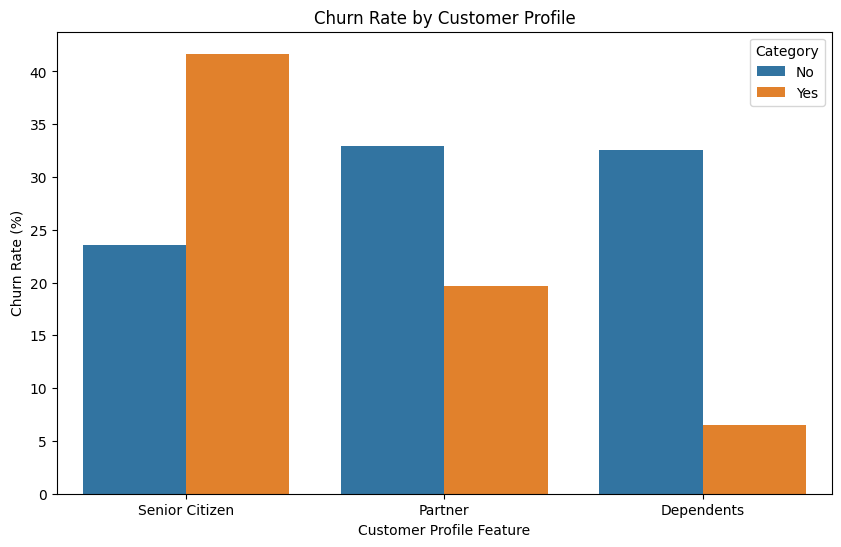

In [37]:
# Visualize churn rate by customer profile

plt.figure(figsize=(10, 6))

sns.barplot(
    data=profile_churn,
    x="Feature",
    y="Churn Rate (%)",
    hue="Category"
)

plt.title("Churn Rate by Customer Profile")
plt.xlabel("Customer Profile Feature")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Category")

plt.show()

# 36. Churn Rate by Additional Services

Customers can subscribe to additional services such as online security, online backup, device protection, and technical support.

These services may be associated with different customer retention patterns.

We will calculate churn rates across the categories of these service features.

The `No internet service` category will be retained because it represents customers who do not have an internet service and therefore cannot subscribe to these internet-dependent services.

In [38]:
# Additional service features to analyze
service_features = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

# Store results
service_churn_results = []

for feature in service_features:
    
    summary = (
        df.groupby(feature)["Churn Value"]
          .agg(["count", "sum", "mean"])
          .reset_index()
    )
    
    # Rename columns
    summary = summary.rename(columns={
        feature: "Category",
        "count": "Total Customers",
        "sum": "Churned Customers",
        "mean": "Churn Rate"
    })
    
    # Convert churn proportion to percentage
    summary["Churn Rate (%)"] = summary["Churn Rate"] * 100
    
    # Add feature name
    summary["Feature"] = feature
    
    # Keep only required columns
    summary = summary[
        [
            "Feature",
            "Category",
            "Total Customers",
            "Churned Customers",
            "Churn Rate (%)"
        ]
    ]
    
    service_churn_results.append(summary)

# Combine all service analyses
service_churn = pd.concat(
    service_churn_results,
    ignore_index=True
)

service_churn

,Feature,Category,Total Customers,Churned Customers,Churn Rate (%)
0,Online Security,No,3498,1461,41.766724
1,Online Security,No internet service,1526,113,7.404980
2,Online Security,Yes,2019,295,14.611194
3,Online Backup,No,3088,1233,39.928756
4,Online Backup,No internet service,1526,113,7.404980
5,Online Backup,Yes,2429,523,21.531494
6,Device Protection,No,3095,1211,39.127625
7,Device Protection,No internet service,1526,113,7.404980
8,Device Protection,Yes,2422,545,22.502064
9,Tech Support,No,3473,1446,41.635474


# 37. Visualize Churn Rate by Additional Services

The previous analysis showed noticeable differences in churn rates across Online Security, Online Backup, Device Protection, and Tech Support.

We will visualize these differences using a grouped bar chart.

The `No internet service` category is retained because it represents a distinct customer state rather than a missing value.

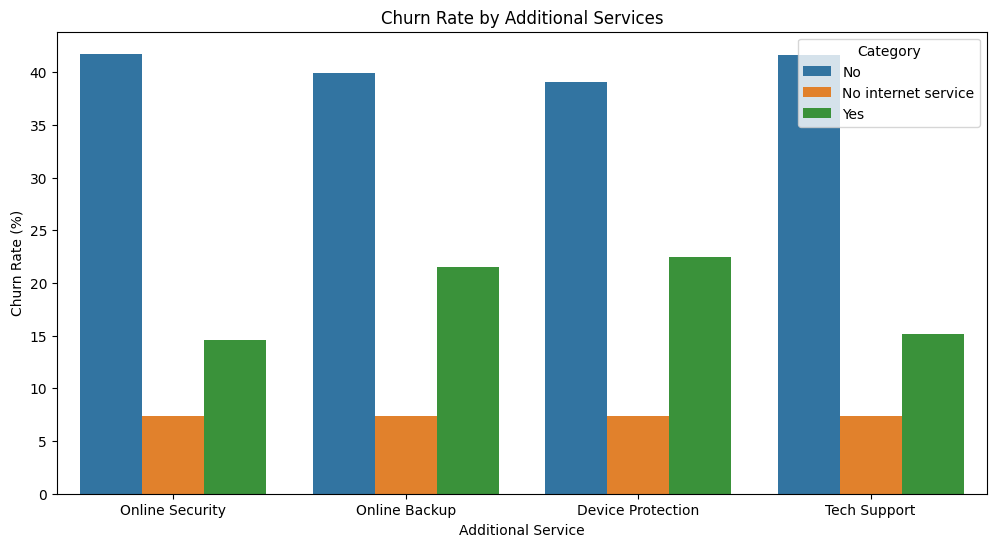

In [39]:
# Visualize churn rate by additional services

plt.figure(figsize=(12, 6))

sns.barplot(
    data=service_churn,
    x="Feature",
    y="Churn Rate (%)",
    hue="Category"
)

plt.title("Churn Rate by Additional Services")
plt.xlabel("Additional Service")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Category")

plt.show()

# 38. Churn Rate by Phone Service

The dataset contains information about whether customers have phone service and whether they subscribe to multiple phone lines.

We will examine:

- `Phone Service`
- `Multiple Lines`

For each feature, we will calculate the total number of customers, number of churned customers, and churn rate.

The `No phone service` category will be retained because it represents customers who do not have phone service rather than customers who have phone service but only use a single line.

In [40]:
# Phone-related features to analyze
phone_features = [
    "Phone Service",
    "Multiple Lines"
]

# Store results
phone_churn_results = []

for feature in phone_features:
    
    summary = (
        df.groupby(feature)["Churn Value"]
          .agg(["count", "sum", "mean"])
          .reset_index()
    )
    
    # Rename columns
    summary = summary.rename(columns={
        feature: "Category",
        "count": "Total Customers",
        "sum": "Churned Customers",
        "mean": "Churn Rate"
    })
    
    # Convert churn proportion to percentage
    summary["Churn Rate (%)"] = summary["Churn Rate"] * 100
    
    # Add feature name
    summary["Feature"] = feature
    
    # Keep required columns
    summary = summary[
        [
            "Feature",
            "Category",
            "Total Customers",
            "Churned Customers",
            "Churn Rate (%)"
        ]
    ]
    
    phone_churn_results.append(summary)

# Combine results
phone_churn = pd.concat(
    phone_churn_results,
    ignore_index=True
)

phone_churn

,Feature,Category,Total Customers,Churned Customers,Churn Rate (%)
0,Phone Service,No,682,170,24.926686
1,Phone Service,Yes,6361,1699,26.709637
2,Multiple Lines,No,3390,849,25.044248
3,Multiple Lines,No phone service,682,170,24.926686
4,Multiple Lines,Yes,2971,850,28.609896


# 39. Visualize Churn Rate by Phone Service

The previous analysis showed relatively small differences in churn rates across phone-service categories.

We will visualize the results to compare the churn rates for `Phone Service` and `Multiple Lines`.

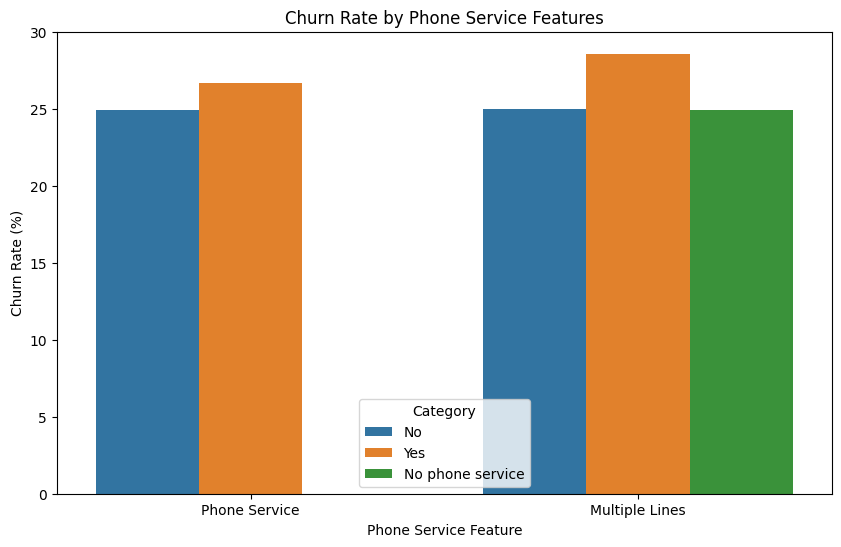

In [41]:
# Visualize churn rate by phone-related features

plt.figure(figsize=(10, 6))

sns.barplot(
    data=phone_churn,
    x="Feature",
    y="Churn Rate (%)",
    hue="Category"
)

plt.title("Churn Rate by Phone Service Features")
plt.xlabel("Phone Service Feature")
plt.ylabel("Churn Rate (%)")
plt.legend(title="Category")

plt.show()

# 40. Churn Rate by Gender

Gender is a demographic variable in the dataset.

We will compare the churn rate between male and female customers to determine whether there is a meaningful difference in observed churn rates.

In [42]:
# Calculate churn rate by gender

gender_churn = (
    df.groupby("Gender")["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Rename columns
gender_churn = gender_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers",
    "mean": "Churn Rate"
})

# Convert churn proportion to percentage
gender_churn["Churn Rate (%)"] = gender_churn["Churn Rate"] * 100

# Keep relevant columns
gender_churn = gender_churn[
    [
        "Gender",
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)"
    ]
]

gender_churn

,Gender,Total Customers,Churned Customers,Churn Rate (%)
0,Female,3488,939,26.920872
1,Male,3555,930,26.160338


# 41. Visualize Churn Rate by Gender

The churn rates for female and male customers are very similar.

We will visualize the results using a simple bar chart to confirm and communicate the comparison clearly.

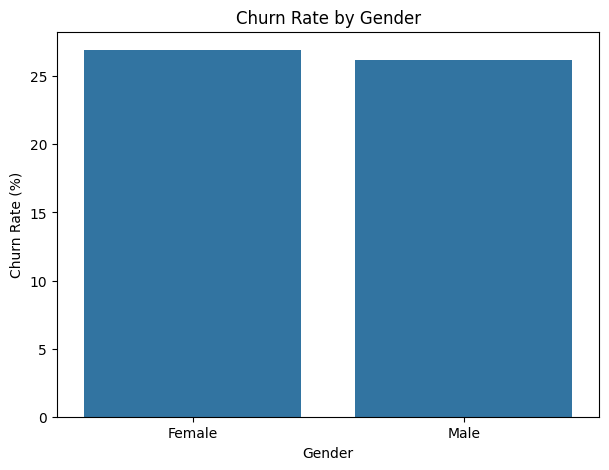

In [43]:
# Visualize churn rate by gender

plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_churn,
    x="Gender",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

# 42. Correlation Analysis

Correlation analysis helps us understand relationships between numerical variables.

We will examine the relationships among:

- `Tenure Months`
- `Monthly Charges`
- `Total Charges`
- `Churn Value`
- `CLTV`

This analysis can help identify relationships between features and detect numerical variables that may contain overlapping information.

Correlation measures linear association and does not imply causation.

In [44]:
# Select numerical variables for correlation analysis

correlation_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Value",
    "CLTV"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_features].corr()

correlation_matrix

,Tenure Months,Monthly Charges,Total Charges,Churn Value,CLTV
Tenure Months,1.000000,0.247900,0.826178,-0.352229,0.396406
Monthly Charges,0.247900,1.000000,0.651174,0.193356,0.098693
Total Charges,0.826178,0.651174,1.000000,-0.198324,0.342091
Churn Value,-0.352229,0.193356,-0.198324,1.000000,-0.127463
CLTV,0.396406,0.098693,0.342091,-0.127463,1.000000


# 43. Correlation Heatmap

The correlation matrix provides numerical values for relationships between the selected numerical variables.

We will visualize the matrix using a heatmap.

A heatmap makes stronger positive and negative correlations easier to identify at a glance.

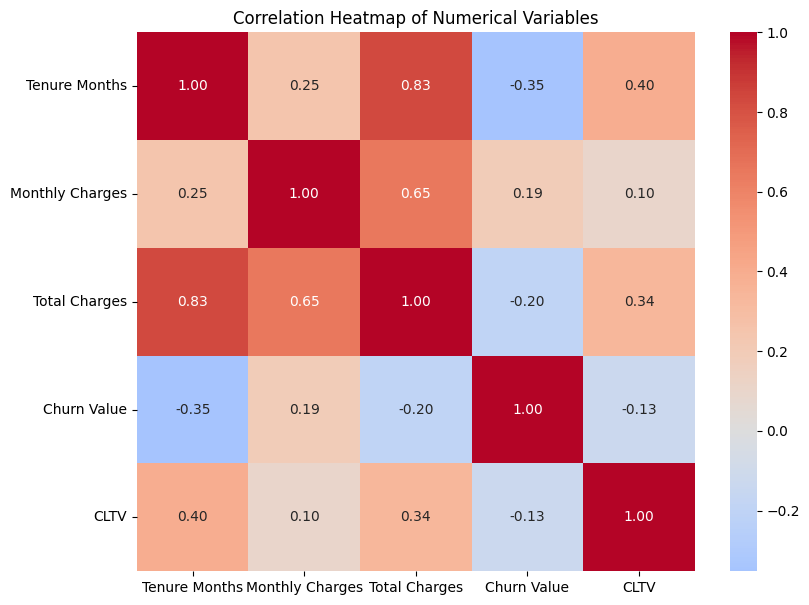

In [45]:
# Create a correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

# 44. Churn Rate by Tenure Groups

Previous analysis showed that churned customers generally have shorter tenure than customers who did not churn.

To make this finding more actionable, we will divide customers into tenure groups and calculate the churn rate for each group.

The tenure groups will represent different stages of the customer lifecycle:

- 0–12 months
- 13–24 months
- 25–36 months
- 37–48 months
- 49–60 months
- 61–72 months

This allows us to identify customer lifecycle stages where churn is more concentrated.

In [46]:
# Create tenure groups

tenure_bins = [0, 12, 24, 36, 48, 60, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "61-72 months"
]

df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Calculate churn statistics by tenure group

tenure_group_churn = (
    df.groupby("Tenure Group", observed=False)["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Rename columns
tenure_group_churn = tenure_group_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers",
    "mean": "Churn Rate"
})

# Convert churn proportion to percentage
tenure_group_churn["Churn Rate (%)"] = (
    tenure_group_churn["Churn Rate"] * 100
)

# Keep relevant columns
tenure_group_churn = tenure_group_churn[
    [
        "Tenure Group",
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)"
    ]
]

tenure_group_churn

,Tenure Group,Total Customers,Churned Customers,Churn Rate (%)
0,0-12 months,2186,1037,47.438243
1,13-24 months,1024,294,28.710938
2,25-36 months,832,180,21.634615
3,37-48 months,762,145,19.028871
4,49-60 months,832,120,14.423077
5,61-72 months,1407,93,6.609808


# 45. Visualize Churn Rate by Tenure Group

The tenure-group analysis showed that observed churn rates decrease across successive tenure ranges.

We will visualize the churn rate for each tenure group to make this customer-lifecycle pattern easier to identify.

This visualization can help communicate which stages of the customer lifecycle have the highest observed churn.

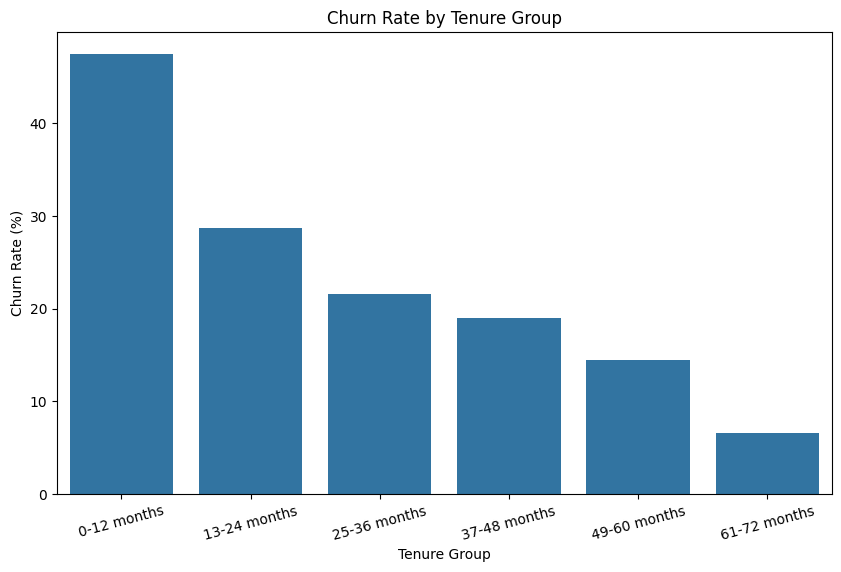

In [47]:
# Visualize churn rate by tenure group

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tenure_group_churn,
    x="Tenure Group",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

# 46. Churn Rate by Paperless Billing

Paperless Billing indicates whether a customer receives billing electronically rather than through a traditional paper bill.

We will compare churn rates between customers with and without paperless billing to determine whether this billing characteristic is associated with different observed churn rates.

In [48]:
# Calculate churn rate by paperless billing

paperless_churn = (
    df.groupby("Paperless Billing")["Churn Value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

# Rename columns
paperless_churn = paperless_churn.rename(columns={
    "count": "Total Customers",
    "sum": "Churned Customers",
    "mean": "Churn Rate"
})

# Convert churn proportion to percentage
paperless_churn["Churn Rate (%)"] = (
    paperless_churn["Churn Rate"] * 100
)

# Keep relevant columns
paperless_churn = paperless_churn[
    [
        "Paperless Billing",
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)"
    ]
]

paperless_churn

,Paperless Billing,Total Customers,Churned Customers,Churn Rate (%)
0,No,2872,469,16.330084
1,Yes,4171,1400,33.565092


# 47. Visualize Churn Rate by Paperless Billing

The previous analysis showed a noticeable difference in observed churn rates between customers with and without paperless billing.

We will visualize this difference using a bar chart.

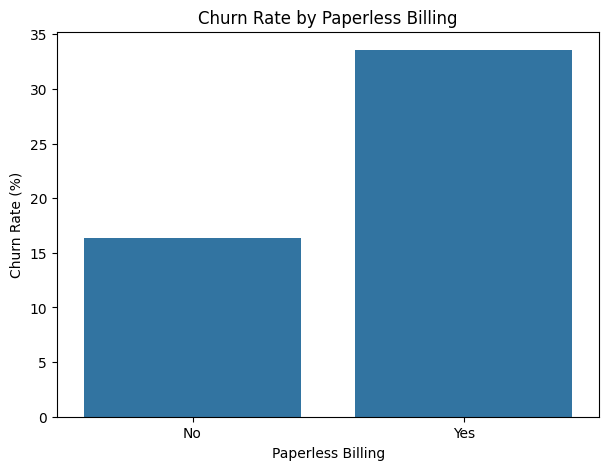

In [49]:
# Visualize churn rate by paperless billing

plt.figure(figsize=(7, 5))

sns.barplot(
    data=paperless_churn,
    x="Paperless Billing",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.show()

# 48. Summary of Key EDA Findings

The exploratory analysis identified several differences in observed churn rates across customer segments and numerical variables.

The summary below consolidates the main findings that may be relevant for subsequent feature engineering, machine learning, and business analysis.

These findings represent associations observed in the dataset and should not be interpreted as causal relationships.

In [50]:
# Create a summary of the key EDA findings

eda_summary = pd.DataFrame({
    "Feature": [
        "Overall Churn",
        "Contract",
        "Internet Service",
        "Payment Method",
        "Tenure",
        "Monthly Charges",
        "Total Charges",
        "Senior Citizen",
        "Partner",
        "Dependents",
        "Paperless Billing",
        "Online Security",
        "Tech Support"
    ],
    
    "Key Observation": [
        "26.54% of customers churned",
        "Month-to-month customers: 42.71% churn",
        "Fiber optic customers: 41.89% churn",
        "Electronic check customers: 45.29% churn",
        "0-12 month customers: 47.44% churn",
        "Churned customers have higher median monthly charges",
        "Churned customers have lower median total charges",
        "Senior citizens: 41.68% churn",
        "Customers without partners: 32.96% churn",
        "Customers without dependents: 32.55% churn",
        "Paperless billing customers: 33.57% churn",
        "Customers without online security: 41.77% churn",
        "Customers without tech support: 41.64% churn"
    ]
})

eda_summary

,Feature,Key Observation
0,Overall Churn,26.54% of customers churned
1,Contract,Month-to-month customers: 42.71% churn
2,Internet Service,Fiber optic customers: 41.89% churn
3,Payment Method,Electronic check customers: 45.29% churn
4,Tenure,0-12 month customers: 47.44% churn
5,Monthly Charges,Churned customers have higher median monthly c...
6,Total Charges,Churned customers have lower median total charges
7,Senior Citizen,Senior citizens: 41.68% churn
8,Partner,Customers without partners: 32.96% churn
9,Dependents,Customers without dependents: 32.55% churn


# 49. Feature Audit

Before building machine learning models, we need to determine which dataset columns should be used as predictors.

Each column will be classified based on its role in the machine learning problem.

We will consider:

- Target variables
- Customer identifiers
- Constant or non-informative columns
- Geographic fields
- Outcome-related fields
- Potential data leakage
- Valid predictive features

The goal is to create a well-defined feature set that represents information that could reasonably be available when predicting future customer churn.

In [51]:
# Display all columns with their data types and number of unique values

feature_audit = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[column].nunique() for column in df.columns]
})

feature_audit

,Column,Data Type,Unique Values
0,CustomerID,object,7043
1,Count,int64,1
2,Country,object,1
3,State,object,1
4,City,object,1129
5,Zip Code,int64,1652
6,Lat Long,object,1652
7,Latitude,float64,1652
8,Longitude,float64,1651
9,Gender,object,2


# 50. Feature Selection Decisions

Based on the feature audit, each column is assigned a role in the machine learning workflow.

The main principles are:

- Remove identifiers that do not provide generalizable information.
- Remove constant columns.
- Remove duplicate representations of the target.
- Remove outcome-derived information that would not be available before churn.
- Exclude the dataset-provided `Churn Score` because it is itself a predictive churn score and creates a strong leakage risk.
- Retain legitimate customer, service, contract, billing, and tenure information.
- Keep `CLTV` under review because it may be useful for business analysis, but its availability at prediction time must be considered.
- Do not use the EDA-only `Tenure Group` in the base model because `Tenure Months` already contains the underlying continuous information.

The target variable is `Churn Value`.

In [52]:
# Create the feature decision table

feature_decisions = [
    ["CustomerID", "Drop", "Customer identifier"],
    ["Count", "Drop", "Constant value"],
    ["Country", "Drop", "Constant value"],
    ["State", "Drop", "Constant value"],
    ["City", "Drop", "High-cardinality geographic feature"],
    ["Zip Code", "Drop", "Geographic identifier"],
    ["Lat Long", "Drop", "Duplicated geographic information"],
    ["Latitude", "Drop", "Geographic feature excluded from base model"],
    ["Longitude", "Drop", "Geographic feature excluded from base model"],
    
    ["Gender", "Keep", "Customer characteristic"],
    ["Senior Citizen", "Keep", "Customer characteristic"],
    ["Partner", "Keep", "Customer characteristic"],
    ["Dependents", "Keep", "Customer characteristic"],
    
    ["Tenure Months", "Keep", "Customer tenure"],
    
    ["Phone Service", "Keep", "Service characteristic"],
    ["Multiple Lines", "Keep", "Service characteristic"],
    ["Internet Service", "Keep", "Service characteristic"],
    ["Online Security", "Keep", "Service characteristic"],
    ["Online Backup", "Keep", "Service characteristic"],
    ["Device Protection", "Keep", "Service characteristic"],
    ["Tech Support", "Keep", "Service characteristic"],
    ["Streaming TV", "Keep", "Service characteristic"],
    ["Streaming Movies", "Keep", "Service characteristic"],
    
    ["Contract", "Keep", "Contract characteristic"],
    ["Paperless Billing", "Keep", "Billing characteristic"],
    ["Payment Method", "Keep", "Billing characteristic"],
    ["Monthly Charges", "Keep", "Recurring charge"],
    ["Total Charges", "Keep", "Accumulated charges"],
    
    ["Churn Label", "Drop", "Duplicate target representation"],
    ["Churn Value", "Target", "Prediction target"],
    ["Churn Score", "Drop", "Predictive churn score; leakage risk"],
    ["CLTV", "Investigate", "Customer lifetime value; verify prediction-time availability"],
    ["Churn Reason", "Drop", "Outcome-derived information"],
    
    ["Tenure Group", "Drop", "EDA-only engineered feature"]
]

# Convert the list into a DataFrame
feature_decisions = pd.DataFrame(
    feature_decisions,
    columns=["Column", "Decision", "Reason"]
)

# Display the feature decision table
feature_decisions

,Column,Decision,Reason
0,CustomerID,Drop,Customer identifier
1,Count,Drop,Constant value
2,Country,Drop,Constant value
3,State,Drop,Constant value
4,City,Drop,High-cardinality geographic feature
5,Zip Code,Drop,Geographic identifier
6,Lat Long,Drop,Duplicated geographic information
7,Latitude,Drop,Geographic feature excluded from base model
8,Longitude,Drop,Geographic feature excluded from base model
9,Gender,Keep,Customer characteristic


# 51. Define Features and Target

Machine learning requires us to separate the dataset into:

- **Features (`X`)**: the input variables used by the model.
- **Target (`y`)**: the outcome that the model is trained to predict.

For this project:

- `X` contains customer demographic, service, contract, billing, and tenure information.
- `y` is `Churn Value`.

We will use an explicit feature list rather than automatically dropping columns. This makes the modeling dataset transparent, reproducible, and easier to explain during an interview.

`CLTV` is temporarily included based on the assumption that it is available at prediction time. We will revisit this assumption before finalizing the model.

In [53]:
# Define the target variable
target_column = "Churn Value"

# Define the features to be used for the initial model
model_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

# Create X and y
X = df[model_features].copy()
y = df[target_column].copy()

# Display the dimensions
print("Feature matrix (X):")
print(f"Rows    : {X.shape[0]}")
print(f"Columns : {X.shape[1]}")

print("\nTarget variable (y):")
print(f"Rows    : {y.shape[0]}")
print(f"Unique values: {sorted(y.unique())}")

Feature matrix (X):
Rows    : 7043
Columns : 20

Target variable (y):
Rows    : 7043
Unique values: [np.int64(0), np.int64(1)]


# 52. Inspect the Feature Matrix

Before preprocessing the feature matrix, we need to identify the data types of our selected predictors.

Machine learning algorithms generally require numerical input, while several of our predictors are categorical variables represented as text.

We will therefore inspect:

- The data types of each feature.
- The number of numerical features.
- The number of categorical features.

This will determine the preprocessing steps required before model training.

In [54]:
# Inspect the data types of the selected features
print("Feature data types:")
print(X.dtypes)

# Separate numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Feature data types:
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
CLTV                   int64
dtype: object

Numerical features:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Number of 

# 53. Split the Data into Training and Test Sets

Before preprocessing and model training, we divide the dataset into training and test sets.

We will use:

- **80% of the data for training**
- **20% of the data for testing**

The training set will be used to learn patterns from historical customer data.

The test set will be kept separate and used to evaluate how well the trained model performs on unseen customers.

Because customer churn is an imbalanced target, we will use **stratified sampling**. This preserves approximately the same proportion of churned and non-churned customers in both datasets.

The split is performed before fitting the preprocessing pipeline to prevent information from the test set from influencing the training process.

In [55]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the resulting dataset sizes
print("Training set:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nTest set:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Training set:
X_train: (5634, 20)
y_train: (5634,)

Test set:
X_test: (1409, 20)
y_test: (1409,)


# 54. Verify Class Distribution After the Train-Test Split

Because customer churn is an imbalanced classification problem, we used stratified sampling when splitting the data.

We will now compare the churn distribution in:

- The full dataset
- The training set
- The test set

The proportions should be very similar.

This confirms that the training and test sets are representative of the original target distribution.

In [56]:
# Calculate churn distribution for the full dataset
full_distribution = y.value_counts(normalize=True).sort_index() * 100

# Calculate churn distribution for the training set
train_distribution = y_train.value_counts(normalize=True).sort_index() * 100

# Calculate churn distribution for the test set
test_distribution = y_test.value_counts(normalize=True).sort_index() * 100

# Combine the distributions into one table
class_distribution = pd.DataFrame({
    "Full Dataset (%)": full_distribution,
    "Training Set (%)": train_distribution,
    "Test Set (%)": test_distribution
})

# Add readable class labels
class_distribution.index = [
    "Did Not Churn (0)",
    "Churned (1)"
]

class_distribution

,Full Dataset (%),Training Set (%),Test Set (%)
Did Not Churn (0),73.463013,73.464679,73.456352
Churned (1),26.536987,26.535321,26.543648


# 55. Build the Preprocessing Pipeline

The feature matrix contains both numerical and categorical variables, so different preprocessing techniques are required.

We will use:

- **StandardScaler** for numerical features.
- **OneHotEncoder** for categorical features.
- **ColumnTransformer** to apply the appropriate transformation to each feature type.

The preprocessing steps will later be incorporated into a machine learning pipeline.

Using a pipeline helps prevent data leakage because preprocessing parameters are learned from the training data and then applied consistently to unseen data.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the numerical preprocessing step
numerical_transformer = StandardScaler()

# Create the categorical preprocessing step
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


# 56. Fit and Apply the Preprocessing Pipeline

The preprocessing pipeline has now been defined.

We will fit the preprocessing pipeline using **only the training features (`X_train`)**.

After fitting:

- The training data will be transformed using the learned preprocessing rules.
- The test data will be transformed using the same rules.

This ensures that information from the test set does not influence the preprocessing process.

The resulting data will be entirely numerical and ready for machine learning algorithms.

In [58]:
# Fit the preprocessor using training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Display the resulting shapes
print("Processed training data shape:", X_train_processed.shape)
print("Processed test data shape:", X_test_processed.shape)

# Check the resulting data type
print("\nProcessed training data type:", type(X_train_processed))

Processed training data shape: (5634, 47)
Processed test data shape: (1409, 47)

Processed training data type: <class 'numpy.ndarray'>


# 57. Inspect the Processed Feature Names

One-hot encoding expands categorical variables into multiple numerical features.

The processed dataset now contains 47 features, compared with the original 20 predictors.

We will retrieve the transformed feature names so that we can understand exactly which variables are being provided to the machine learning models.

This is also important for later model interpretation and Explainable AI analysis.

In [59]:
# Retrieve the names of the transformed features
processed_feature_names = preprocessor.get_feature_names_out()

# Display the feature names
print("Number of processed features:", len(processed_feature_names))

print("\nProcessed feature names:")
for i, feature in enumerate(processed_feature_names, start=1):
    print(f"{i:2}. {feature}")

Number of processed features: 47

Processed feature names:
 1. num__Tenure Months
 2. num__Monthly Charges
 3. num__Total Charges
 4. num__CLTV
 5. cat__Gender_Female
 6. cat__Gender_Male
 7. cat__Senior Citizen_No
 8. cat__Senior Citizen_Yes
 9. cat__Partner_No
10. cat__Partner_Yes
11. cat__Dependents_No
12. cat__Dependents_Yes
13. cat__Phone Service_No
14. cat__Phone Service_Yes
15. cat__Multiple Lines_No
16. cat__Multiple Lines_No phone service
17. cat__Multiple Lines_Yes
18. cat__Internet Service_DSL
19. cat__Internet Service_Fiber optic
20. cat__Internet Service_No
21. cat__Online Security_No
22. cat__Online Security_No internet service
23. cat__Online Security_Yes
24. cat__Online Backup_No
25. cat__Online Backup_No internet service
26. cat__Online Backup_Yes
27. cat__Device Protection_No
28. cat__Device Protection_No internet service
29. cat__Device Protection_Yes
30. cat__Tech Support_No
31. cat__Tech Support_No internet service
32. cat__Tech Support_Yes
33. cat__Streaming TV_No

# 58. Establish a Majority-Class Baseline

Before training machine learning models, we establish a simple baseline for comparison.

The majority class in the dataset is:

- `0` = Did not churn

A majority-class baseline predicts the majority class for every customer.

This provides a minimum reference point for evaluating whether our machine learning models are learning useful patterns.

Because customer churn is an imbalanced classification problem, accuracy alone can be misleading. A model that predicts every customer as non-churn could achieve relatively high accuracy while failing to identify any churned customers.

We will therefore evaluate the baseline using multiple classification metrics.

In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create a majority-class baseline model
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Train the baseline model
baseline_model.fit(X_train_processed, y_train)

# Generate predictions on the test set
y_baseline_pred = baseline_model.predict(X_test_processed)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_test, y_baseline_pred)
baseline_precision = precision_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)
baseline_recall = recall_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)
baseline_f1 = f1_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)

# Display baseline metrics
print("Baseline Model Performance")
print("=" * 35)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_baseline_pred))

Baseline Model Performance
Accuracy : 0.7346
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Confusion Matrix:
[[1035    0]
 [ 374    0]]


# 59. Train the First Machine Learning Model: Logistic Regression

We will now train our first supervised machine learning model using Logistic Regression.

Logistic Regression is a suitable starting point because this project is a binary classification problem.

The model estimates the probability that a customer belongs to the churn class.

We will evaluate the model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Recall is particularly important for this project because failing to identify a customer who is likely to churn may result in a missed retention opportunity.

In [61]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

# Generate predictions on the test set
y_logistic_pred = logistic_model.predict(X_test_processed)

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_logistic_pred)
logistic_precision = precision_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)
logistic_recall = recall_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)
logistic_f1 = f1_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)

# Display results
print("Logistic Regression Performance")
print("=" * 40)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_logistic_pred))

Logistic Regression Performance
Accuracy : 0.8020
Precision: 0.6426
Recall   : 0.5722
F1 Score : 0.6054

Confusion Matrix:
[[916 119]
 [160 214]]


# 60. Train a Random Forest Classifier

We will now train a Random Forest classifier as our second machine learning model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to make predictions.

Compared with Logistic Regression, Random Forest can capture:

- Non-linear relationships.
- Interactions between features.
- More complex customer behavior patterns.

We will evaluate it using the same metrics as Logistic Regression so that the models can be compared fairly.

In [62]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

# Generate predictions on the test set
y_rf_pred = random_forest_model.predict(X_test_processed)

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_precision = precision_score(
    y_test,
    y_rf_pred,
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    y_rf_pred,
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    y_rf_pred,
    zero_division=0
)

# Display results
print("Random Forest Performance")
print("=" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_rf_pred))

Random Forest Performance
Accuracy : 0.7942
Precision: 0.6373
Recall   : 0.5214
F1 Score : 0.5735

Confusion Matrix:
[[924 111]
 [179 195]]


# 61. Train an XGBoost Classifier

We will now train an XGBoost classifier as the third machine learning model.

XGBoost is a gradient-boosting algorithm that builds decision trees sequentially, with each new tree attempting to improve the errors made by the previous trees.

It is well suited to structured/tabular datasets and can model non-linear relationships and interactions between features.

We will evaluate XGBoost using the same metrics used for the previous models:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Using the same evaluation procedure allows us to compare the models fairly.

In [63]:
from xgboost import XGBClassifier

# Create the XGBoost model
xgboost_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgboost_model.fit(X_train_processed, y_train)

# Generate predictions on the test set
y_xgb_pred = xgboost_model.predict(X_test_processed)

# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_xgb_pred)
xgb_precision = precision_score(
    y_test,
    y_xgb_pred,
    zero_division=0
)
xgb_recall = recall_score(
    y_test,
    y_xgb_pred,
    zero_division=0
)
xgb_f1 = f1_score(
    y_test,
    y_xgb_pred,
    zero_division=0
)

# Display results
print("XGBoost Performance")
print("=" * 35)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_xgb_pred))

XGBoost Performance
Accuracy : 0.7935
Precision: 0.6301
Recall   : 0.5374
F1 Score : 0.5801

Confusion Matrix:
[[917 118]
 [173 201]]


# 62. Compare Initial Model Performance

We have now evaluated three machine learning models against the majority-class baseline:

- Majority-Class Baseline
- Logistic Regression
- Random Forest
- XGBoost

We will combine their evaluation metrics into a single comparison table.

This allows us to compare the models consistently using accuracy, precision, recall, and F1 score.

At this stage, these are initial model results using the same train-test split. We will perform further model improvement and threshold analysis before selecting a final modeling approach.

In [64]:
# Create a comparison table for the initial models
model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        baseline_precision,
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        baseline_recall,
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        baseline_f1,
        logistic_f1,
        rf_f1,
        xgb_f1
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Baseline,0.734564,0.000000,0.000000,0.000000
1,Logistic Regression,0.801987,0.642643,0.572193,0.605375
2,Random Forest,0.794180,0.637255,0.521390,0.573529
3,XGBoost,0.793471,0.630094,0.537433,0.580087


# 63. Evaluate ROC-AUC

Accuracy, precision, recall, and F1 score depend on a classification threshold.

Our models also produce continuous churn probabilities, which contain more information than the final 0/1 predictions.

We will calculate the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) using the predicted probability of the churn class.

ROC-AUC measures how well a model separates churned customers from customers who did not churn across different classification thresholds.

A higher ROC-AUC indicates better ranking/separation ability.

We will calculate ROC-AUC for Logistic Regression, Random Forest, and XGBoost using the same test set.

In [65]:
from sklearn.metrics import roc_auc_score

# Generate churn probabilities for each model
y_logistic_proba = logistic_model.predict_proba(X_test_processed)[:, 1]
y_rf_proba = random_forest_model.predict_proba(X_test_processed)[:, 1]
y_xgb_proba = xgboost_model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC-AUC
logistic_roc_auc = roc_auc_score(y_test, y_logistic_proba)
rf_roc_auc = roc_auc_score(y_test, y_rf_proba)
xgb_roc_auc = roc_auc_score(y_test, y_xgb_proba)

# Display ROC-AUC results
print("ROC-AUC Performance")
print("=" * 30)
print(f"Logistic Regression: {logistic_roc_auc:.4f}")
print(f"Random Forest      : {rf_roc_auc:.4f}")
print(f"XGBoost            : {xgb_roc_auc:.4f}")

ROC-AUC Performance
Logistic Regression: 0.8489
Random Forest      : 0.8396
XGBoost            : 0.8485


# 64. Update the Model Comparison with ROC-AUC

We will extend our initial model comparison by adding ROC-AUC.

This gives us two complementary perspectives:

- Threshold-dependent metrics: Accuracy, Precision, Recall and F1 Score.
- Threshold-independent ranking metric: ROC-AUC.

The majority-class baseline is excluded from the ROC-AUC comparison because it does not provide meaningful probability-based ranking information for this analysis.

In [66]:
# Create an updated model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942
1,Random Forest,0.794180,0.637255,0.521390,0.573529,0.839619
2,XGBoost,0.793471,0.630094,0.537433,0.580087,0.848503


# 65. Tune Logistic Regression Hyperparameters

The initial Logistic Regression model used a single configuration.

We will now use `GridSearchCV` to evaluate multiple hyperparameter combinations using cross-validation.

The primary optimization metric will be **F1 Score**, because the churn problem requires a balance between precision and recall.

We will tune the regularization strength (`C`) and the regularization type (`penalty`).

The test set will remain untouched during hyperparameter tuning. Cross-validation will be performed only on the training data.

This prevents the test set from influencing model selection.

In [67]:
from sklearn.model_selection import GridSearchCV

# Create a fresh Logistic Regression model
logistic_tuning_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Define the hyperparameter search space
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"]
}

# Create the GridSearchCV object
logistic_grid_search = GridSearchCV(
    estimator=logistic_tuning_model,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Perform cross-validation using training data only
logistic_grid_search.fit(
    X_train_processed,
    y_train
)

# Display the best configuration
print("Best Logistic Regression parameters:")
print(logistic_grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{logistic_grid_search.best_score_:.4f}")

Best Logistic Regression parameters:
{'C': 1, 'penalty': 'l2'}

Best cross-validation F1 score:
0.6231


C:\Users\Reddy\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


# 66. Evaluate the Tuned Logistic Regression

GridSearchCV identified the best Logistic Regression configuration using five-fold cross-validation on the training data.

We will now evaluate the selected model on the untouched test set.

This provides an unbiased estimate of how the tuned model performs on unseen data.

We will compare its performance with the original Logistic Regression model using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

In [68]:
# Retrieve the best Logistic Regression model
tuned_logistic_model = logistic_grid_search.best_estimator_

# Generate predictions on the untouched test set
y_tuned_logistic_pred = tuned_logistic_model.predict(X_test_processed)

# Generate churn probabilities
y_tuned_logistic_proba = tuned_logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# Calculate evaluation metrics
tuned_logistic_accuracy = accuracy_score(
    y_test,
    y_tuned_logistic_pred
)

tuned_logistic_precision = precision_score(
    y_test,
    y_tuned_logistic_pred,
    zero_division=0
)

tuned_logistic_recall = recall_score(
    y_test,
    y_tuned_logistic_pred,
    zero_division=0
)

tuned_logistic_f1 = f1_score(
    y_test,
    y_tuned_logistic_pred,
    zero_division=0
)

tuned_logistic_roc_auc = roc_auc_score(
    y_test,
    y_tuned_logistic_proba
)

# Display results
print("Tuned Logistic Regression Performance")
print("=" * 45)
print(f"Accuracy : {tuned_logistic_accuracy:.4f}")
print(f"Precision: {tuned_logistic_precision:.4f}")
print(f"Recall   : {tuned_logistic_recall:.4f}")
print(f"F1 Score : {tuned_logistic_f1:.4f}")
print(f"ROC-AUC  : {tuned_logistic_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_tuned_logistic_pred))

Tuned Logistic Regression Performance
Accuracy : 0.8020
Precision: 0.6426
Recall   : 0.5722
F1 Score : 0.6054
ROC-AUC  : 0.8489

Confusion Matrix:
[[916 119]
 [160 214]]


## Step 67 — Leakage-Safe Logistic Regression Tuning

To tune Logistic Regression correctly, preprocessing should be included inside the machine learning pipeline.

This ensures that during cross-validation, the preprocessing steps are fitted only on the training portion of each fold.

We will use:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Logistic Regression as the classifier
- GridSearchCV with 5-fold cross-validation
- F1 Score as the tuning metric

Using F1 Score is appropriate because churn prediction involves an imbalanced target, and we want to balance precision and recall rather than optimize accuracy alone.

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a fresh preprocessing pipeline
pipeline_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Create the complete machine learning pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", pipeline_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Hyperparameter grid
logistic_pipeline_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
logistic_pipeline_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_pipeline_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Fit using RAW training data
logistic_pipeline_grid_search.fit(X_train, y_train)

# Display results
print("Best Parameters:")
print(logistic_pipeline_grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{logistic_pipeline_grid_search.best_score_:.4f}")

Best Parameters:
{'classifier__C': 10}

Best Cross-Validation F1 Score:
0.6240


## Step 68 — Evaluate the Properly Tuned Logistic Regression

The best Logistic Regression pipeline identified through 5-fold cross-validation will now be evaluated on the untouched test set.

We will calculate:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

The test set was not used during hyperparameter tuning, so it provides an unbiased estimate of the model's performance on unseen data.

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Get the best leakage-safe pipeline
final_tuned_logistic = logistic_pipeline_grid_search.best_estimator_

# Predictions on the untouched test set
y_final_logistic_pred = final_tuned_logistic.predict(X_test)

# Probability predictions for ROC-AUC
y_final_logistic_proba = final_tuned_logistic.predict_proba(X_test)[:, 1]

# Calculate performance metrics
final_logistic_accuracy = accuracy_score(
    y_test,
    y_final_logistic_pred
)

final_logistic_precision = precision_score(
    y_test,
    y_final_logistic_pred
)

final_logistic_recall = recall_score(
    y_test,
    y_final_logistic_pred
)

final_logistic_f1 = f1_score(
    y_test,
    y_final_logistic_pred
)

final_logistic_roc_auc = roc_auc_score(
    y_test,
    y_final_logistic_proba
)

# Display results
print("Properly Tuned Logistic Regression Performance")
print("=" * 50)
print(f"Accuracy : {final_logistic_accuracy:.4f}")
print(f"Precision: {final_logistic_precision:.4f}")
print(f"Recall   : {final_logistic_recall:.4f}")
print(f"F1 Score : {final_logistic_f1:.4f}")
print(f"ROC-AUC  : {final_logistic_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_final_logistic_pred))

Properly Tuned Logistic Regression Performance
Accuracy : 0.7977
Precision: 0.6320
Recall   : 0.5695
F1 Score : 0.5992
ROC-AUC  : 0.8481

Confusion Matrix:
[[911 124]
 [161 213]]


## Step 69 — Classification Threshold Analysis

Logistic Regression produces a probability of churn for each customer.

By default, a customer is classified as likely to churn when the predicted probability is at least 0.50.

However, the 0.50 threshold is not necessarily optimal for a customer retention strategy.

A lower threshold can identify more potential churners, increasing recall, but may also increase the number of false positives.

We will evaluate different classification thresholds using cross-validated predictions from the training data.

The test set will remain untouched and will only be used for final model evaluation.

In [71]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold churn probabilities
y_train_cv_proba = cross_val_predict(
    final_tuned_logistic,
    X_train,
    y_train,
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Cross-validated probabilities generated.")
print(f"Number of predictions: {len(y_train_cv_proba)}")
print(f"Minimum probability: {y_train_cv_proba.min():.4f}")
print(f"Maximum probability: {y_train_cv_proba.max():.4f}")

Cross-validated probabilities generated.
Number of predictions: 5634
Minimum probability: 0.0004
Maximum probability: 0.8647


In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Thresholds to evaluate
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    
    # Convert probabilities into class predictions
    y_train_threshold_pred = (
        y_train_cv_proba >= threshold
    ).astype(int)
    
    # Calculate metrics
    precision = precision_score(
        y_train,
        y_train_threshold_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_train,
        y_train_threshold_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_train,
        y_train_threshold_pred,
        zero_division=0
    )
    
    customers_flagged = y_train_threshold_pred.sum()
    
    threshold_results.append([
        threshold,
        precision,
        recall,
        f1,
        customers_flagged
    ])

# Create results DataFrame
threshold_results = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score",
        "Customers Flagged"
    ]
)

threshold_results

,Threshold,Precision,Recall,F1 Score,Customers Flagged
0,0.20,0.489872,0.873579,0.627734,2666
1,0.25,0.523749,0.826087,0.641059,2358
2,0.30,0.552919,0.779264,0.646863,2107
3,0.35,0.580457,0.731104,0.647128,1883
4,0.40,0.609161,0.684950,0.644836,1681
5,0.45,0.632735,0.636120,0.634423,1503
6,0.50,0.667174,0.585953,0.623932,1313
7,0.55,0.693333,0.521739,0.595420,1125
8,0.60,0.726395,0.452843,0.557890,932
9,0.65,0.755618,0.359866,0.487540,712


## Step 70 — Business Impact and Retention Campaign Simulation

A churn prediction model can support targeted customer retention campaigns.

Instead of evaluating the model only using statistical metrics, we can estimate the potential business impact of contacting customers identified as high risk.

For this portfolio analysis, we will use illustrative business assumptions:

- Retention campaign cost per contacted customer: ₹500
- Estimated value of successfully retained customer: ₹5,000

These values are hypothetical assumptions for demonstrating the business impact framework. They are not values provided by the IBM Telco dataset.

For each classification threshold, we will estimate:

- Number of customers contacted
- Number of actual churners identified
- Campaign cost
- Potential retained-customer value
- Estimated net benefit

The analysis is intended to demonstrate how model predictions can be translated into business decisions.

In [73]:
# Illustrative business assumptions
campaign_cost_per_customer = 500
value_per_retained_customer = 5000

# Create a copy of the threshold results
business_impact = threshold_results.copy()

# Calculate estimated number of actual churners identified
# using recall × total actual churners in the training data
total_actual_churners = y_train.sum()

business_impact["Churners Identified"] = (
    business_impact["Recall"] * total_actual_churners
).round().astype(int)

# Campaign cost
business_impact["Campaign Cost"] = (
    business_impact["Customers Flagged"]
    * campaign_cost_per_customer
)

# Estimated value from successfully retained customers
business_impact["Potential Retention Value"] = (
    business_impact["Churners Identified"]
    * value_per_retained_customer
)

# Estimated net benefit
business_impact["Estimated Net Benefit"] = (
    business_impact["Potential Retention Value"]
    - business_impact["Campaign Cost"]
)

business_impact

,Threshold,Precision,Recall,F1 Score,Customers Flagged,Churners Identified,Campaign Cost,Potential Retention Value,Estimated Net Benefit
0,0.20,0.489872,0.873579,0.627734,2666,1306,1333000,6530000,5197000
1,0.25,0.523749,0.826087,0.641059,2358,1235,1179000,6175000,4996000
2,0.30,0.552919,0.779264,0.646863,2107,1165,1053500,5825000,4771500
3,0.35,0.580457,0.731104,0.647128,1883,1093,941500,5465000,4523500
4,0.40,0.609161,0.684950,0.644836,1681,1024,840500,5120000,4279500
5,0.45,0.632735,0.636120,0.634423,1503,951,751500,4755000,4003500
6,0.50,0.667174,0.585953,0.623932,1313,876,656500,4380000,3723500
7,0.55,0.693333,0.521739,0.595420,1125,780,562500,3900000,3337500
8,0.60,0.726395,0.452843,0.557890,932,677,466000,3385000,2919000
9,0.65,0.755618,0.359866,0.487540,712,538,356000,2690000,2334000


## Step 70.2 — Retention Success Scenario Analysis

Identifying a customer who is likely to churn does not guarantee that a retention campaign will successfully retain that customer.

To make the business-impact analysis more realistic, we introduce a hypothetical retention success rate.

We will evaluate four scenarios:

- 10% retention success
- 20% retention success
- 30% retention success
- 40% retention success

These are illustrative assumptions and are not derived from the IBM Telco Customer Churn dataset.

The purpose is to demonstrate sensitivity analysis and show how the expected business value changes depending on campaign effectiveness.

In [74]:
# Illustrative retention success-rate scenarios
retention_success_rates = [0.10, 0.20, 0.30, 0.40]

scenario_results = []

for retention_rate in retention_success_rates:
    
    scenario = business_impact.copy()
    
    # Estimated successfully retained customers
    scenario["Retention Success Rate"] = retention_rate
    
    scenario["Estimated Customers Retained"] = (
        scenario["Churners Identified"] * retention_rate
    ).round().astype(int)
    
    # Estimated value actually recovered
    scenario["Estimated Recovered Value"] = (
        scenario["Estimated Customers Retained"]
        * value_per_retained_customer
    )
    
    # Campaign cost remains the same
    scenario["Net Benefit"] = (
        scenario["Estimated Recovered Value"]
        - scenario["Campaign Cost"]
    )
    
    scenario_results.append(scenario)

# Combine all scenarios
scenario_results_df = pd.concat(
    scenario_results,
    ignore_index=True
)

scenario_results_df[
    [
        "Threshold",
        "Retention Success Rate",
        "Customers Flagged",
        "Churners Identified",
        "Estimated Customers Retained",
        "Campaign Cost",
        "Estimated Recovered Value",
        "Net Benefit"
    ]
]

,Threshold,Retention Success Rate,Customers Flagged,Churners Identified,Estimated Customers Retained,Campaign Cost,Estimated Recovered Value,Net Benefit
0,0.20,0.1,2666,1306,131,1333000,655000,-678000
1,0.25,0.1,2358,1235,124,1179000,620000,-559000
2,0.30,0.1,2107,1165,116,1053500,580000,-473500
3,0.35,0.1,1883,1093,109,941500,545000,-396500
4,0.40,0.1,1681,1024,102,840500,510000,-330500
5,0.45,0.1,1503,951,95,751500,475000,-276500
6,0.50,0.1,1313,876,88,656500,440000,-216500
7,0.55,0.1,1125,780,78,562500,390000,-172500
8,0.60,0.1,932,677,68,466000,340000,-126000
9,0.65,0.1,712,538,54,356000,270000,-86000


## Step 71 — Break-Even Retention Analysis

The profitability of a retention campaign depends on how many contacted churn-risk customers can actually be retained.

Rather than selecting a single threshold based only on model metrics, we calculate the minimum retention success rate required for the campaign to break even.

Break-even retention rate is calculated as:

Break-even Retention Rate =
Campaign Cost / (Churners Identified × Value per Retained Customer)

This provides a business interpretation of each classification threshold.

A lower break-even retention rate means the campaign requires less success to cover its cost under the stated assumptions.

The campaign cost and customer value remain illustrative assumptions.

In [75]:
# Calculate break-even retention rate for each threshold

break_even_analysis = business_impact.copy()

break_even_analysis["Break-Even Retention Rate"] = (
    break_even_analysis["Campaign Cost"]
    / (
        break_even_analysis["Churners Identified"]
        * value_per_retained_customer
    )
)

break_even_analysis[
    [
        "Threshold",
        "Customers Flagged",
        "Churners Identified",
        "Campaign Cost",
        "Break-Even Retention Rate"
    ]
]

,Threshold,Customers Flagged,Churners Identified,Campaign Cost,Break-Even Retention Rate
0,0.20,2666,1306,1333000,0.204135
1,0.25,2358,1235,1179000,0.190931
2,0.30,2107,1165,1053500,0.180858
3,0.35,1883,1093,941500,0.172278
4,0.40,1681,1024,840500,0.164160
5,0.45,1503,951,751500,0.158044
6,0.50,1313,876,656500,0.149886
7,0.55,1125,780,562500,0.144231
8,0.60,932,677,466000,0.137666
9,0.65,712,538,356000,0.132342


## Step 72 — Final Test-Set Evaluation at the Selected Threshold

The threshold analysis identified 0.35 as the strongest tested threshold based on cross-validated F1 score.

We will now apply this threshold to the untouched test set.

This provides a final estimate of how the churn model performs on unseen customers when used with the selected classification threshold.

We will report:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Number of customers flagged for retention

The ROC-AUC remains threshold-independent because it uses predicted probabilities rather than binary predictions.

In [76]:
# Selected threshold based on cross-validated F1 analysis
selected_threshold = 0.35

# Convert test-set probabilities into predictions
y_test_threshold_pred = (
    y_final_logistic_proba >= selected_threshold
).astype(int)

# Calculate metrics
threshold_test_accuracy = accuracy_score(
    y_test,
    y_test_threshold_pred
)

threshold_test_precision = precision_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

threshold_test_recall = recall_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

threshold_test_f1 = f1_score(
    y_test,
    y_test_threshold_pred,
    zero_division=0
)

threshold_test_roc_auc = roc_auc_score(
    y_test,
    y_final_logistic_proba
)

# Number of customers flagged
test_customers_flagged = y_test_threshold_pred.sum()

# Confusion matrix
threshold_test_confusion = confusion_matrix(
    y_test,
    y_test_threshold_pred
)

print("Final Test-Set Performance at Threshold 0.35")
print("=" * 55)
print(f"Accuracy : {threshold_test_accuracy:.4f}")
print(f"Precision: {threshold_test_precision:.4f}")
print(f"Recall   : {threshold_test_recall:.4f}")
print(f"F1 Score : {threshold_test_f1:.4f}")
print(f"ROC-AUC  : {threshold_test_roc_auc:.4f}")

print(f"\nCustomers Flagged for Retention: {test_customers_flagged}")

print("\nConfusion Matrix:")
print(threshold_test_confusion)

Final Test-Set Performance at Threshold 0.35
Accuracy : 0.7786
Precision: 0.5649
Recall   : 0.7219
F1 Score : 0.6338
ROC-AUC  : 0.8481

Customers Flagged for Retention: 478

Confusion Matrix:
[[827 208]
 [104 270]]


## Step 73 — Logistic Regression Coefficient Analysis

Logistic Regression provides coefficients that describe how each processed feature is associated with the model's predicted churn probability.

Positive coefficients indicate that the feature increases the model's log-odds of churn, while negative coefficients indicate a decrease.

Because categorical variables were one-hot encoded, the coefficients correspond to individual encoded categories.

We will examine the largest positive and negative coefficients to understand which customer characteristics have the strongest influence on the model's predictions.

Coefficient analysis describes model behavior and association. It does not establish causation.

In [77]:
# Extract the fitted preprocessor and classifier
fitted_preprocessor = final_tuned_logistic.named_steps["preprocessor"]
fitted_classifier = final_tuned_logistic.named_steps["classifier"]

# Get feature names after preprocessing
processed_feature_names = fitted_preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
logistic_coefficients = fitted_classifier.coef_[0]

# Create a DataFrame
coefficient_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Coefficient": logistic_coefficients
})

# Calculate absolute coefficient size
coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

# Sort by coefficient magnitude
coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficient_df.head(20)

,Feature,Coefficient,Absolute Coefficient
1,num__Monthly Charges,-1.745648,1.745648
0,num__Tenure Months,-1.324765,1.324765
18,cat__Internet Service_Fiber optic,1.139426,1.139426
11,cat__Dependents_Yes,-1.050144,1.050144
17,cat__Internet Service_DSL,-1.046776,1.046776
40,cat__Contract_Two year,-0.798273,0.798273
10,cat__Dependents_No,0.594189,0.594189
2,num__Total Charges,0.567984,0.567984
19,cat__Internet Service_No,-0.548605,0.548605
30,cat__Tech Support_No internet service,-0.548605,0.548605


## Step 73.2 — Strongest Positive and Negative Model Signals

To make the Logistic Regression model easier to interpret, we will separate the processed features into:

- Features with positive coefficients, associated with higher predicted churn log-odds
- Features with negative coefficients, associated with lower predicted churn log-odds

We will examine the strongest signals by absolute coefficient magnitude.

These results describe model behavior and associations, not causal relationships.

In [78]:
# Strongest positive coefficients
positive_coefficients = (
    coefficient_df[coefficient_df["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

# Strongest negative coefficients
negative_coefficients = (
    coefficient_df[coefficient_df["Coefficient"] < 0]
    .sort_values("Coefficient", ascending=True)
    .head(10)
)

print("Strongest Positive Coefficients")
print("=" * 45)
display(positive_coefficients)

print("\nStrongest Negative Coefficients")
print("=" * 45)
display(negative_coefficients)

Strongest Positive Coefficients


,Feature,Coefficient,Absolute Coefficient
18,cat__Internet Service_Fiber optic,1.139426,1.139426
10,cat__Dependents_No,0.594189,0.594189
2,num__Total Charges,0.567984,0.567984
38,cat__Contract_Month-to-month,0.539262,0.539262
34,cat__Streaming TV_Yes,0.449063,0.449063
37,cat__Streaming Movies_Yes,0.437806,0.437806
16,cat__Multiple Lines_Yes,0.286692,0.286692
28,cat__Device Protection_Yes,0.159378,0.159378
45,cat__Payment Method_Electronic check,0.158014,0.158014
25,cat__Online Backup_Yes,0.111731,0.111731



Strongest Negative Coefficients


,Feature,Coefficient,Absolute Coefficient
1,num__Monthly Charges,-1.745648,1.745648
0,num__Tenure Months,-1.324765,1.324765
11,cat__Dependents_Yes,-1.050144,1.050144
17,cat__Internet Service_DSL,-1.046776,1.046776
40,cat__Contract_Two year,-0.798273,0.798273
19,cat__Internet Service_No,-0.548605,0.548605
30,cat__Tech Support_No internet service,-0.548605,0.548605
27,cat__Device Protection_No internet service,-0.548605,0.548605
21,cat__Online Security_No internet service,-0.548605,0.548605
24,cat__Online Backup_No internet service,-0.548605,0.548605


## Step 74 — Logistic Regression Odds Ratios

Logistic Regression coefficients are expressed in log-odds units, which can be difficult to interpret directly.

To make the model more interpretable, we convert each coefficient into an odds ratio:

Odds Ratio = exp(Coefficient)

Interpretation:

- Odds Ratio > 1 indicates higher modeled odds of churn.
- Odds Ratio < 1 indicates lower modeled odds of churn.
- Odds Ratio close to 1 indicates a relatively small association.

The odds ratios describe the model's conditional associations and should not be interpreted as causal effects.

In [79]:
import numpy as np

# Create a copy of the coefficient table
odds_ratio_df = coefficient_df.copy()

# Convert coefficients to odds ratios
odds_ratio_df["Odds Ratio"] = np.exp(
    odds_ratio_df["Coefficient"]
)

# Sort by absolute coefficient magnitude
odds_ratio_df = odds_ratio_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

# Display the strongest model signals
odds_ratio_df.head(20)

,Feature,Coefficient,Absolute Coefficient,Odds Ratio
1,num__Monthly Charges,-1.745648,1.745648,0.174532
0,num__Tenure Months,-1.324765,1.324765,0.265865
18,cat__Internet Service_Fiber optic,1.139426,1.139426,3.124975
11,cat__Dependents_Yes,-1.050144,1.050144,0.349888
17,cat__Internet Service_DSL,-1.046776,1.046776,0.351068
40,cat__Contract_Two year,-0.798273,0.798273,0.450106
10,cat__Dependents_No,0.594189,0.594189,1.811560
2,num__Total Charges,0.567984,0.567984,1.764705
19,cat__Internet Service_No,-0.548605,0.548605,0.577755
30,cat__Tech Support_No internet service,-0.548605,0.548605,0.577755


## Step 75 — Visualizing Logistic Regression Coefficients

A coefficient plot provides a visual summary of the strongest model signals.

Positive coefficients indicate higher modeled churn log-odds, while negative coefficients indicate lower modeled churn log-odds.

Only the strongest coefficients are displayed to keep the visualization interpretable.

The plot represents model associations and should not be interpreted as evidence of causation.

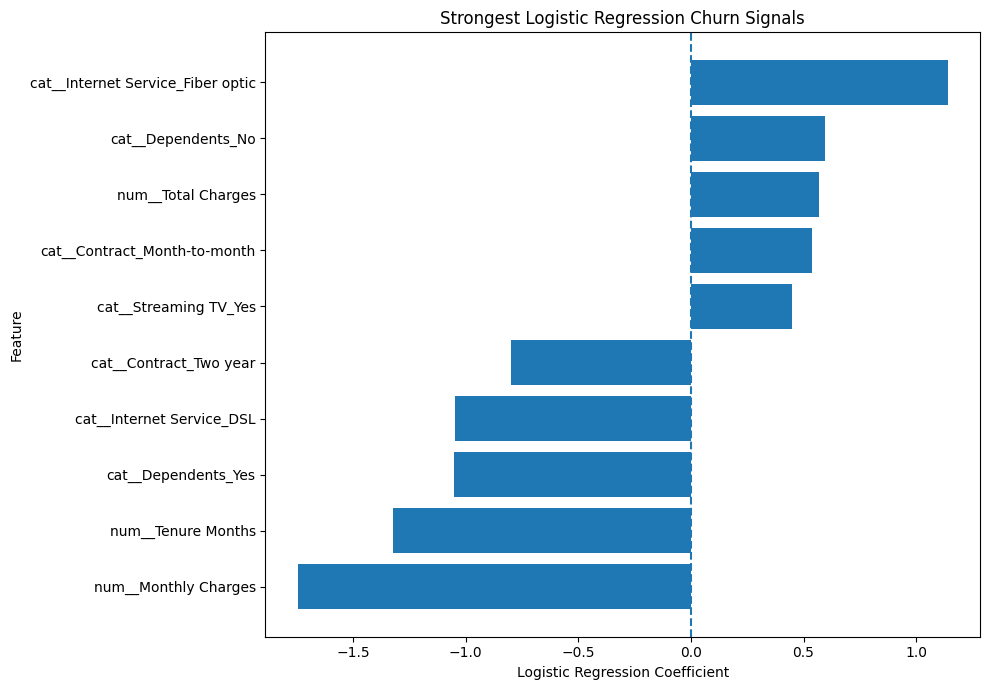

In [80]:
import matplotlib.pyplot as plt

# Select the 10 strongest positive and negative coefficients
top_positive = (
    coefficient_df[coefficient_df["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
    .head(5)
)

top_negative = (
    coefficient_df[coefficient_df["Coefficient"] < 0]
    .sort_values("Coefficient", ascending=True)
    .head(5)
)

# Combine the strongest positive and negative signals
top_coefficients = pd.concat(
    [top_negative, top_positive]
).sort_values("Coefficient")

# Create the plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Logistic Regression Churn Signals")

plt.tight_layout()
plt.show()

## Step 76 — SHAP Explainability

SHAP (SHapley Additive exPlanations) provides model explanations by estimating how individual features contribute to predictions.

We will use SHAP to understand:

- Which features are most influential overall
- Whether feature values tend to increase or decrease churn predictions
- How individual customer predictions can be explained

SHAP explanations describe model behavior and do not establish causal relationships.

We will begin with global feature importance using the XGBoost model.

In [81]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Create SHAP TreeExplainer for the trained XGBoost model
xgb_explainer = shap.TreeExplainer(xgboost_model)

# Calculate SHAP values for the test set
xgb_shap_values = xgb_explainer.shap_values(
    X_test_processed
)

# Get processed feature names
xgb_feature_names = preprocessor.get_feature_names_out()

# Create a SHAP importance table
shap_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Mean Absolute SHAP": abs(xgb_shap_values).mean(axis=0)
})

# Sort by importance
shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

# Display the top 20 features
shap_importance.head(20)

,Feature,Mean Absolute SHAP
38,cat__Contract_Month-to-month,0.854829
10,cat__Dependents_No,0.574714
0,num__Tenure Months,0.511630
1,num__Monthly Charges,0.251830
20,cat__Online Security_No,0.218332
18,cat__Internet Service_Fiber optic,0.188648
29,cat__Tech Support_No,0.183448
2,num__Total Charges,0.159384
45,cat__Payment Method_Electronic check,0.157782
14,cat__Multiple Lines_No,0.129704


## Step 76.2 — Global SHAP Feature Importance

The mean absolute SHAP values show which features have the greatest overall influence on the XGBoost model's predictions.

A horizontal bar chart will be used to make the relative importance of the features easier to compare.

This visualization shows feature influence magnitude, but not the direction of the influence.

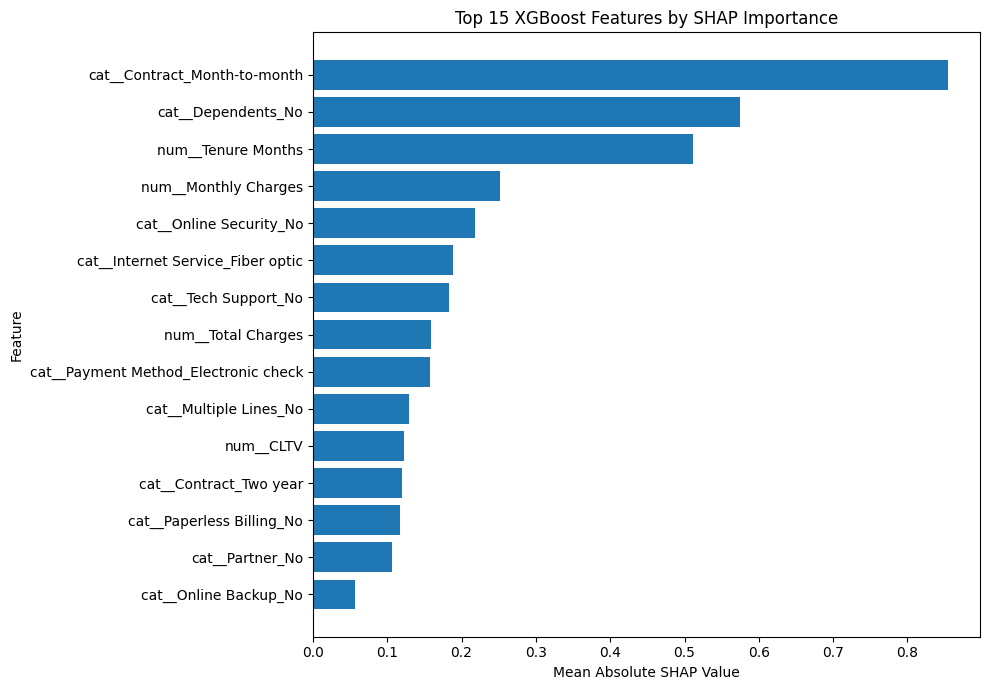

In [82]:
# Select the top 15 SHAP features
top_shap_features = (
    shap_importance
    .head(15)
    .sort_values("Mean Absolute SHAP")
)

# Create the visualization
plt.figure(figsize=(10, 7))

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features by SHAP Importance")

plt.tight_layout()
plt.show()

## Step 76.3 — SHAP Direction Analysis

Mean absolute SHAP values show the magnitude of each feature's influence, but they do not show whether a feature increases or decreases the predicted churn risk.

A SHAP summary plot allows us to examine both:

- Feature importance
- Direction of influence

Features on the right side of the SHAP axis push predictions toward higher churn risk, while features on the left push predictions toward lower churn risk.

For categorical features, the encoded value represents the presence or absence of that category.

SHAP values explain model behavior and should not be interpreted as causal effects.

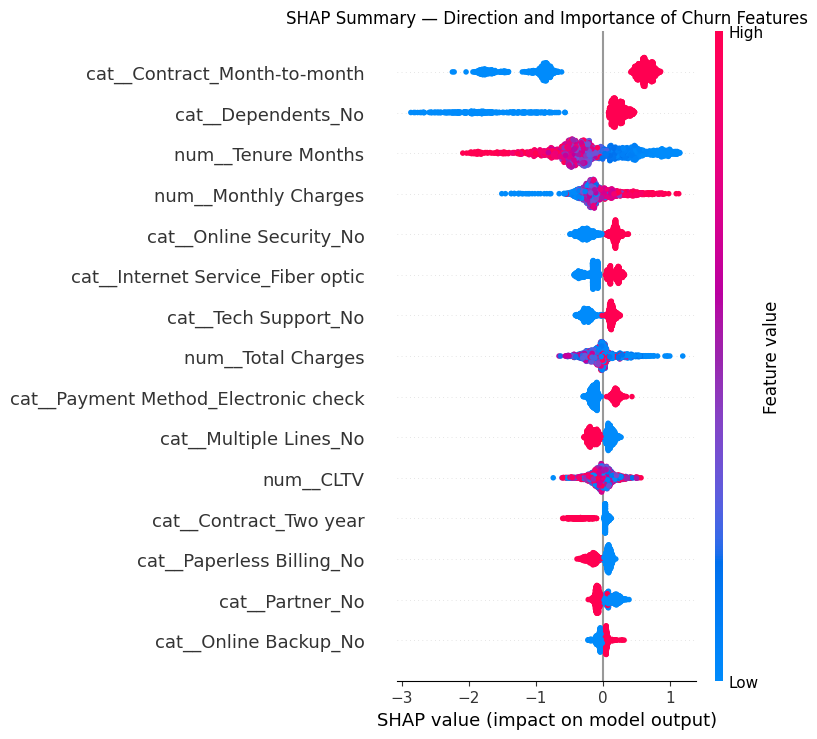

In [83]:
# SHAP summary plot showing feature importance and direction

plt.figure(figsize=(10, 8))

shap.summary_plot(
    xgb_shap_values,
    X_test_processed,
    feature_names=xgb_feature_names,
    max_display=15,
    show=False
)

plt.title("SHAP Summary — Direction and Importance of Churn Features")
plt.tight_layout()
plt.show()

## Step 77 — Individual Customer SHAP Explanation

Global SHAP analysis explains which features influence the model across the customer population.

We will now perform a local explanation for one individual customer.

The goal is to understand why the XGBoost model assigned a particular customer a higher or lower churn probability.

We will select a test customer with a relatively high predicted churn probability and examine the individual SHAP contributions.

Positive SHAP values push the prediction toward higher churn risk, while negative SHAP values push it toward lower churn risk.

This explains the model's prediction for the selected customer and does not imply causal effects.

In [84]:
# Find a high-risk customer in the test set
high_risk_index = np.argmax(y_xgb_proba)

# Get the original customer data
high_risk_customer = X_test.iloc[high_risk_index]

# Get the actual churn outcome
high_risk_actual = y_test.iloc[high_risk_index]

# Get the predicted churn probability
high_risk_probability = y_xgb_proba[high_risk_index]

print("Selected Customer for Local SHAP Explanation")
print("=" * 55)

print("\nCustomer Features:")
display(high_risk_customer.to_frame(name="Value"))

print(f"\nActual Churn Value: {high_risk_actual}")
print(f"Predicted Churn Probability: {high_risk_probability:.4f}")

Selected Customer for Local SHAP Explanation

Customer Features:


,Value
Gender,Male
Senior Citizen,Yes
Partner,Yes
Dependents,No
Tenure Months,1
Phone Service,Yes
Multiple Lines,Yes
Internet Service,Fiber optic
Online Security,No
Online Backup,No



Actual Churn Value: 1
Predicted Churn Probability: 0.9534


## Step 77.2 — Individual Customer SHAP Contributions

We will examine the SHAP contributions for the selected high-risk customer.

Each SHAP value represents how a processed feature contributes to the XGBoost model output for this individual customer.

- Positive SHAP values push the prediction toward higher churn risk.
- Negative SHAP values push the prediction toward lower churn risk.
- Values close to zero have relatively little influence on this prediction.

We will rank the contributions by absolute magnitude to identify the features that had the greatest influence on this customer's prediction.

SHAP values explain the model's behavior and do not establish causation.

In [85]:
# Get SHAP values for the selected high-risk customer
customer_shap_values = xgb_shap_values[high_risk_index]

# Create a DataFrame containing the customer's SHAP contributions
customer_shap_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "SHAP Value": customer_shap_values
})

# Calculate absolute contribution magnitude
customer_shap_df["Absolute SHAP"] = (
    customer_shap_df["SHAP Value"].abs()
)

# Sort by contribution magnitude
customer_shap_df = customer_shap_df.sort_values(
    "Absolute SHAP",
    ascending=False
)

# Display the top 15 contributions
customer_shap_df.head(15)

,Feature,SHAP Value,Absolute SHAP
0,num__Tenure Months,1.080412,1.080412
38,cat__Contract_Month-to-month,0.744151,0.744151
1,num__Monthly Charges,0.246098,0.246098
10,cat__Dependents_No,0.198819,0.198819
14,cat__Multiple Lines_No,0.197963,0.197963
18,cat__Internet Service_Fiber optic,0.196911,0.196911
29,cat__Tech Support_No,0.195197,0.195197
2,num__Total Charges,0.185509,0.185509
45,cat__Payment Method_Electronic check,0.183406,0.183406
20,cat__Online Security_No,0.167153,0.167153


## Step 77.3 — Individual Customer SHAP Visualization

We will visualize the strongest SHAP contributions for the selected customer.

Positive SHAP values indicate contributions toward higher model output, while negative values indicate contributions toward lower model output.

This visualization provides a local explanation of why the XGBoost model assigned this customer a high churn probability.

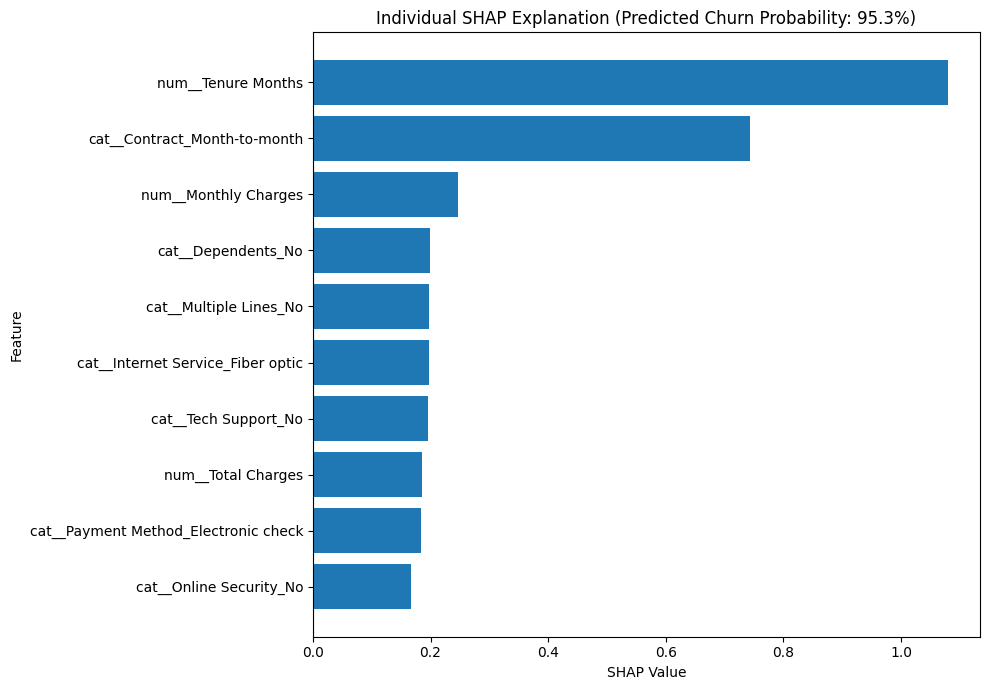

In [86]:
# Select the 10 strongest SHAP contributions
top_customer_shap = (
    customer_shap_df
    .head(10)
    .sort_values("SHAP Value")
)

# Create the plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_customer_shap["Feature"],
    top_customer_shap["SHAP Value"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"Individual SHAP Explanation "
    f"(Predicted Churn Probability: {high_risk_probability:.1%})"
)

plt.tight_layout()
plt.show()

## Step 78 — Customer Churn Risk Table

The final Logistic Regression pipeline will be used to generate customer-level churn probabilities.

A classification threshold of 0.35 was selected through cross-validated threshold analysis and evaluated once on the untouched test set.

Customers with predicted churn probability at or above 0.35 will be flagged as higher-risk customers for potential retention activity.

The risk table will contain customer-level predictions and selected customer attributes.

Actual churn outcomes are included for model evaluation in this notebook but would not be available when making predictions for future customers.

In [87]:
# Selected threshold from our cross-validated analysis
selected_threshold = 0.35

# Generate final Logistic Regression probabilities for the test set
final_risk_probabilities = final_tuned_logistic.predict_proba(X_test)[:, 1]

# Create binary churn predictions
final_risk_predictions = (
    final_risk_probabilities >= selected_threshold
).astype(int)

# Recover Customer IDs using the original test-set indices
customer_ids = df.loc[X_test.index, "CustomerID"]

# Create the customer risk table
customer_risk_table = X_test.copy()

customer_risk_table.insert(
    0,
    "CustomerID",
    customer_ids
)

# Add model outputs
customer_risk_table["Churn Probability"] = (
    final_risk_probabilities
)

customer_risk_table["Risk Level"] = np.where(
    final_risk_probabilities >= selected_threshold,
    "High Risk",
    "Lower Risk"
)

customer_risk_table["Retention Flag"] = np.where(
    final_risk_probabilities >= selected_threshold,
    "Yes",
    "No"
)

# Add actual outcome for evaluation purposes
customer_risk_table["Actual Churn"] = y_test.values

# Sort highest-risk customers first
customer_risk_table = customer_risk_table.sort_values(
    "Churn Probability",
    ascending=False
)

# Display the first 20 high-risk customers
customer_risk_table.head(20)

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn Probability,Risk Level,Retention Flag,Actual Churn
886,5178-LMXOP,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,5795,0.883397,High Risk,Yes,1
2567,6630-UJZMY,Female,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,83.25,308.05,5251,0.857269,High Risk,Yes,0
684,6861-XWTWQ,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,2487,0.852911,High Risk,Yes,1
1818,0295-PPHDO,Male,No,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,5962,0.844536,High Risk,Yes,1
590,7181-BQYBV,Female,No,Yes,No,1,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,102.45,102.45,4811,0.839453,High Risk,Yes,1
1827,1400-MMYXY,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,2715,0.837727,High Risk,Yes,1
3732,4927-WWOOZ,Male,No,Yes,No,2,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,91.45,171.45,4889,0.832687,High Risk,Yes,0
1681,8884-ADFVN,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,2016,0.831994,High Risk,Yes,1
598,7180-PISOG,Male,No,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.50,74.50,5554,0.831912,High Risk,Yes,1
4845,8161-QYMTT,Male,No,No,No,7,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.10,701.30,5259,0.829598,High Risk,Yes,0


## Step 79 — Customer Risk Segment Summary

Customer-level predictions can be aggregated into risk segments to support business reporting.

We will compare customers flagged for retention with customers not flagged.

The summary will include:

- Number of customers
- Percentage of customers
- Average predicted churn probability
- Number of actual churners
- Observed churn rate

The actual churn outcome is used only for historical model evaluation. In a real deployment, future churn outcomes would not yet be known.

In [88]:
# Create risk segment summary
risk_segment_summary = (
    customer_risk_table
    .groupby("Risk Level")
    .agg(
        Customers=("CustomerID", "count"),
        Average_Churn_Probability=("Churn Probability", "mean"),
        Actual_Churners=("Actual Churn", "sum"),
        Observed_Churn_Rate=("Actual Churn", "mean")
    )
    .reset_index()
)

# Calculate percentage of all customers
risk_segment_summary["Customer_Percentage"] = (
    risk_segment_summary["Customers"]
    / len(customer_risk_table)
    * 100
)

# Convert rates to percentages
risk_segment_summary["Observed_Churn_Rate"] = (
    risk_segment_summary["Observed_Churn_Rate"] * 100
)

# Reorder columns
risk_segment_summary = risk_segment_summary[
    [
        "Risk Level",
        "Customers",
        "Customer_Percentage",
        "Average_Churn_Probability",
        "Actual_Churners",
        "Observed_Churn_Rate"
    ]
]

# Sort high-risk customers first
risk_segment_summary = risk_segment_summary.sort_values(
    "Risk Level",
    ascending=True
)

risk_segment_summary

,Risk Level,Customers,Customer_Percentage,Average_Churn_Probability,Actual_Churners,Observed_Churn_Rate
0,High Risk,478,33.924769,0.589858,270,56.485356
1,Lower Risk,931,66.075231,0.101349,104,11.170784


## Step 80 — Risk Segment Visualization

We will visualize the observed churn rate for customers classified as High Risk and Lower Risk.

This helps communicate whether the model's risk segmentation separates customers with different historical churn outcomes.

The observed churn rate is calculated using the historical test-set outcomes and would not be available for future customers at prediction time.

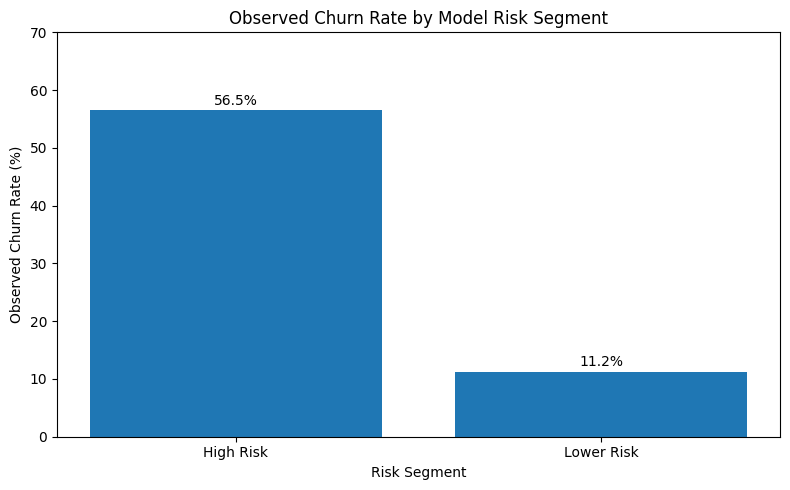

In [89]:
# Prepare data for visualization
risk_chart_data = risk_segment_summary[
    ["Risk Level", "Observed_Churn_Rate"]
].copy()

# Rename for readability
risk_chart_data = risk_chart_data.rename(
    columns={
        "Observed_Churn_Rate": "Observed Churn Rate"
    }
)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    risk_chart_data["Risk Level"],
    risk_chart_data["Observed Churn Rate"]
)

plt.ylabel("Observed Churn Rate (%)")
plt.xlabel("Risk Segment")
plt.title("Observed Churn Rate by Model Risk Segment")

# Add value labels
for index, value in enumerate(
    risk_chart_data["Observed Churn Rate"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 70)
plt.tight_layout()
plt.show()

## Step 81 — Consolidated Model Evaluation

This section consolidates the major model evaluation results into a single comparison table.

The comparison includes:

- Logistic Regression
- Random Forest
- XGBoost

For Logistic Regression, we also report the final selected classification threshold of 0.35.

The default 0.50 threshold and the selected 0.35 threshold are compared to demonstrate the trade-off between precision and recall.

ROC-AUC is threshold-independent because it evaluates the ranking of predicted probabilities across classification thresholds.

In [90]:
# Default Logistic Regression metrics
default_logistic_pred = logistic_model.predict(X_test_processed)
default_logistic_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# Create consolidated evaluation table
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (0.50)",
        "Logistic Regression (0.35)",
        "Random Forest (0.50)",
        "XGBoost (0.50)"
    ],
    "Accuracy": [
        accuracy_score(y_test, default_logistic_pred),
        threshold_test_accuracy,
        accuracy_score(y_test, y_rf_pred),
        accuracy_score(y_test, y_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, default_logistic_pred, zero_division=0),
        threshold_test_precision,
        precision_score(y_test, y_rf_pred, zero_division=0),
        precision_score(y_test, y_xgb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, default_logistic_pred, zero_division=0),
        threshold_test_recall,
        recall_score(y_test, y_rf_pred, zero_division=0),
        recall_score(y_test, y_xgb_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, default_logistic_pred, zero_division=0),
        threshold_test_f1,
        f1_score(y_test, y_rf_pred, zero_division=0),
        f1_score(y_test, y_xgb_pred, zero_division=0)
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        threshold_test_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (0.50),0.801987,0.642643,0.572193,0.605375,0.848942
1,Logistic Regression (0.35),0.778566,0.564854,0.721925,0.633803,0.848097
2,Random Forest (0.50),0.794180,0.637255,0.521390,0.573529,0.839619
3,XGBoost (0.50),0.793471,0.630094,0.537433,0.580087,0.848503


## Step 82 — Final Confusion Matrix

The confusion matrix shows how the final Logistic Regression model performed on the untouched test set using the selected 0.35 probability threshold.

It separates predictions into:

- True Negatives
- False Positives
- False Negatives
- True Positives

For churn prediction, false negatives represent customers who actually churned but were not flagged for retention.

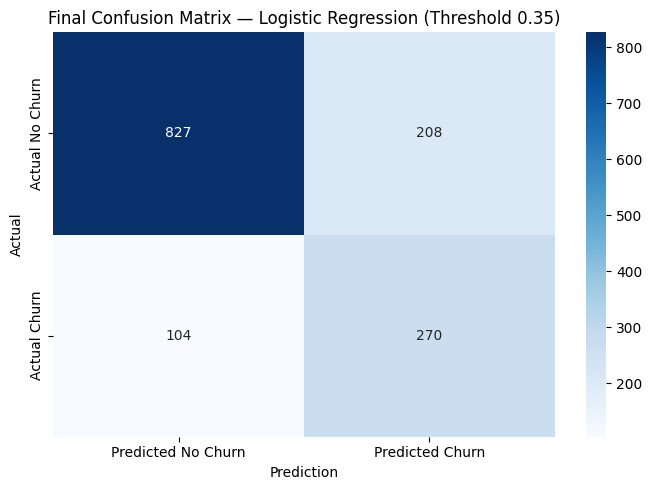

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate final confusion matrix
final_confusion_matrix = confusion_matrix(
    y_test,
    y_test_threshold_pred
)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix — Logistic Regression (Threshold 0.35)")

plt.tight_layout()
plt.show()

## Step 83 — Final Model Evaluation Summary

The final churn prediction workflow combines model performance, threshold selection, and customer-level risk segmentation.

The Logistic Regression model was evaluated using a default probability threshold of 0.50 and a selected threshold of 0.35.

The 0.35 threshold was selected through cross-validated threshold analysis and subsequently evaluated once on the untouched test set.

At the 0.35 threshold, the model achieved:

- Accuracy: 77.86%
- Precision: 56.49%
- Recall: 72.19%
- F1 Score: 63.38%
- ROC-AUC: 84.81%

The model identified 270 of the 374 actual churners in the test set, resulting in 104 false negatives.

The threshold therefore prioritizes identifying a larger proportion of potential churners at the cost of lower precision and more false positives.

Model evaluation should be interpreted alongside the business objective rather than relying on accuracy alone.

In [92]:
# Final evaluation summary

final_evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Test Customers",
        "Customers Flagged",
        "True Positives",
        "False Positives",
        "True Negatives",
        "False Negatives"
    ],
    "Value": [
        threshold_test_accuracy,
        threshold_test_precision,
        threshold_test_recall,
        threshold_test_f1,
        threshold_test_roc_auc,
        len(y_test),
        test_customers_flagged,
        threshold_test_confusion[1, 1],
        threshold_test_confusion[0, 1],
        threshold_test_confusion[0, 0],
        threshold_test_confusion[1, 0]
    ]
})

final_evaluation_summary

,Metric,Value
0,Accuracy,0.778566
1,Precision,0.564854
2,Recall,0.721925
3,F1 Score,0.633803
4,ROC-AUC,0.848097
5,Test Customers,1409.000000
6,Customers Flagged,478.000000
7,True Positives,270.000000
8,False Positives,208.000000
9,True Negatives,827.000000


## Step 84 — Business Insights

The objective of the business analysis is to translate the exploratory analysis and machine learning results into actionable customer-retention insights.

The analysis identified several customer characteristics associated with different observed churn rates and several features that strongly influenced the machine learning predictions.

Key areas examined include:

- Contract type
- Customer tenure
- Internet service
- Dependents
- Online security
- Technical support
- Payment method
- Monthly charges
- Model-based customer risk

These findings describe observed associations and model behavior. They should not be interpreted as proof that any individual factor directly causes churn.

In [93]:
business_insights = pd.DataFrame({
    "Business Area": [
        "Contract",
        "Tenure",
        "Internet Service",
        "Dependents",
        "Online Security",
        "Tech Support",
        "Payment Method",
        "Risk Segmentation"
    ],
    "Observed Finding": [
        "Month-to-month customers had substantially higher observed churn than one-year and two-year customers.",
        "Short-tenure customers had higher observed churn, with churn declining across longer tenure groups.",
        "Fiber-optic customers had higher observed churn than DSL and customers without internet service.",
        "Customers without dependents had substantially higher observed churn than customers with dependents.",
        "Customers without online security had higher observed churn than customers with online security.",
        "Customers without technical support had higher observed churn than customers with technical support.",
        "Electronic-check customers had higher observed churn than the automatic payment groups.",
        "Customers flagged High Risk had a substantially higher observed churn rate than Lower Risk customers."
    ],
    "Evidence": [
        "Month-to-month: 42.71% churn",
        "0–12 months: 47.44% churn; 61–72 months: 6.61%",
        "Fiber optic: 41.89% churn; DSL: 18.96%",
        "No dependents: 32.55%; dependents: 6.52%",
        "No online security: 41.77%; yes: 14.61%",
        "No tech support: 41.64%; yes: 15.17%",
        "Electronic check: 45.29% churn",
        "High Risk: 56.49%; Lower Risk: 11.17%"
    ]
})

business_insights

,Business Area,Observed Finding,Evidence
0,Contract,Month-to-month customers had substantially hig...,Month-to-month: 42.71% churn
1,Tenure,Short-tenure customers had higher observed chu...,0–12 months: 47.44% churn; 61–72 months: 6.61%
2,Internet Service,Fiber-optic customers had higher observed chur...,Fiber optic: 41.89% churn; DSL: 18.96%
3,Dependents,Customers without dependents had substantially...,No dependents: 32.55%; dependents: 6.52%
4,Online Security,Customers without online security had higher o...,No online security: 41.77%; yes: 14.61%
5,Tech Support,Customers without technical support had higher...,No tech support: 41.64%; yes: 15.17%
6,Payment Method,Electronic-check customers had higher observed...,Electronic check: 45.29% churn
7,Risk Segmentation,Customers flagged High Risk had a substantiall...,High Risk: 56.49%; Lower Risk: 11.17%


## Step 85 — Retention Strategy Mapping

The identified churn patterns can be translated into potential retention strategies.

These recommendations are hypotheses for business intervention rather than causal conclusions.

The objective is to align potential retention actions with the customer characteristics and risk signals identified during EDA and machine learning analysis.

Potential interventions should be validated through controlled experiments or business testing before being deployed at scale.

In [94]:
retention_strategy = pd.DataFrame({
    "Risk Signal": [
        "Month-to-month contract",
        "Short customer tenure",
        "Fiber-optic service",
        "No online security",
        "No technical support",
        "Electronic check",
        "High predicted churn probability"
    ],
    "Observed Evidence": [
        "42.71% churn rate",
        "0–12 month customers: 47.44% churn",
        "41.89% churn rate",
        "41.77% churn rate",
        "41.64% churn rate",
        "45.29% churn rate",
        "High-risk segment: 56.49% observed churn"
    ],
    "Potential Retention Action": [
        "Test contract-renewal incentives or longer-term plan options.",
        "Design an early-tenure onboarding and engagement program.",
        "Investigate service experience and targeted support for fiber customers.",
        "Test education, trial, or bundled offers for security services.",
        "Offer proactive technical support or service-health outreach.",
        "Test alternative payment options and payment-method assistance.",
        "Prioritize high-risk customers for targeted retention campaigns."
    ],
    "Validation Approach": [
        "A/B test eligible customers offered contract incentives.",
        "Compare churn among customers receiving enhanced onboarding with a control group.",
        "Investigate customer-service records and test targeted interventions.",
        "Measure adoption and subsequent churn against a control group.",
        "Measure whether proactive support changes retention outcomes.",
        "Track payment-method changes and subsequent retention.",
        "Run a controlled retention campaign and compare outcomes."
    ]
})

retention_strategy

,Risk Signal,Observed Evidence,Potential Retention Action,Validation Approach
0,Month-to-month contract,42.71% churn rate,Test contract-renewal incentives or longer-ter...,A/B test eligible customers offered contract i...
1,Short customer tenure,0–12 month customers: 47.44% churn,Design an early-tenure onboarding and engageme...,Compare churn among customers receiving enhanc...
2,Fiber-optic service,41.89% churn rate,Investigate service experience and targeted su...,Investigate customer-service records and test ...
3,No online security,41.77% churn rate,"Test education, trial, or bundled offers for s...",Measure adoption and subsequent churn against ...
4,No technical support,41.64% churn rate,Offer proactive technical support or service-h...,Measure whether proactive support changes rete...
5,Electronic check,45.29% churn rate,Test alternative payment options and payment-m...,Track payment-method changes and subsequent re...
6,High predicted churn probability,High-risk segment: 56.49% observed churn,Prioritize high-risk customers for targeted re...,Run a controlled retention campaign and compar...


## Step 86 — Retention and Revenue Impact Scenario Analysis

The model identifies customers who may be suitable for retention activity.

To estimate potential business impact, we perform a scenario analysis using different assumed retention success rates.

Assumptions:

- Campaign cost per targeted customer: 500
- Estimated value of each successfully retained customer: 5,000
- Retention success rate represents the proportion of identified churners who are successfully retained.

Net benefit is calculated as:

Net Benefit = Estimated Recovered Value − Campaign Cost

These values are hypothetical business assumptions for scenario analysis and do not represent measured revenue or guaranteed financial outcomes.

In [95]:
# Business assumptions
campaign_cost_per_customer = 500
retained_customer_value = 5000

# Use the final threshold-based test predictions
flagged_customers = (
    final_risk_probabilities >= selected_threshold
)

# Number of flagged customers
num_flagged_customers = flagged_customers.sum()

# Actual churners among flagged customers
actual_churners_flagged = (
    y_test.values[flagged_customers].sum()
)

# Retention success-rate scenarios
retention_success_rates = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

revenue_scenarios = []

for success_rate in retention_success_rates:

    estimated_retained = round(
        actual_churners_flagged * success_rate
    )

    campaign_cost = (
        num_flagged_customers
        * campaign_cost_per_customer
    )

    estimated_recovered_value = (
        estimated_retained
        * retained_customer_value
    )

    net_benefit = (
        estimated_recovered_value
        - campaign_cost
    )

    revenue_scenarios.append([
        success_rate,
        num_flagged_customers,
        actual_churners_flagged,
        estimated_retained,
        campaign_cost,
        estimated_recovered_value,
        net_benefit
    ])

revenue_scenarios = pd.DataFrame(
    revenue_scenarios,
    columns=[
        "Retention Success Rate",
        "Customers Flagged",
        "Actual Churners Flagged",
        "Estimated Customers Retained",
        "Campaign Cost",
        "Estimated Recovered Value",
        "Estimated Net Benefit"
    ]
)

revenue_scenarios

,Retention Success Rate,Customers Flagged,Actual Churners Flagged,Estimated Customers Retained,Campaign Cost,Estimated Recovered Value,Estimated Net Benefit
0,0.1,478,270,27,239000,135000,-104000
1,0.2,478,270,54,239000,270000,31000
2,0.3,478,270,81,239000,405000,166000
3,0.4,478,270,108,239000,540000,301000
4,0.5,478,270,135,239000,675000,436000


## Step 86.2 — Break-Even Retention Rate

The break-even retention rate represents the minimum proportion of identified churners that would need to be successfully retained for the hypothetical retention campaign to recover its campaign cost.

The calculation is:

Break-Even Retention Rate =
Campaign Cost / (Actual Churners Flagged × Retained Customer Value)

This is a scenario-based financial estimate using the assumptions defined above. It should not be interpreted as a measured or guaranteed business outcome.

In [96]:
# Calculate break-even retention rate
break_even_retention_rate = (
    campaign_cost_per_customer * num_flagged_customers
) / (
    actual_churners_flagged * retained_customer_value
)

print("Break-Even Retention Analysis")
print("=" * 45)

print(f"Customers Flagged: {num_flagged_customers}")
print(f"Actual Churners Flagged: {actual_churners_flagged}")
print(f"Campaign Cost: {campaign_cost_per_customer * num_flagged_customers:,.0f}")
print(f"Retained Customer Value: {retained_customer_value:,.0f}")
print(
    f"Break-Even Retention Rate: "
    f"{break_even_retention_rate:.2%}"
)

Break-Even Retention Analysis
Customers Flagged: 478
Actual Churners Flagged: 270
Campaign Cost: 239,000
Retained Customer Value: 5,000
Break-Even Retention Rate: 17.70%


## Step 87 — Retention Scenario Visualization

The scenario analysis estimates how the financial outcome of a hypothetical retention campaign changes as the retention success rate varies.

The visualization shows the estimated net benefit under retention success rates from 10% to 50%.

A positive net benefit indicates that the estimated recovered value exceeds the assumed campaign cost.

These are scenario-based estimates and should not be interpreted as realized financial results.

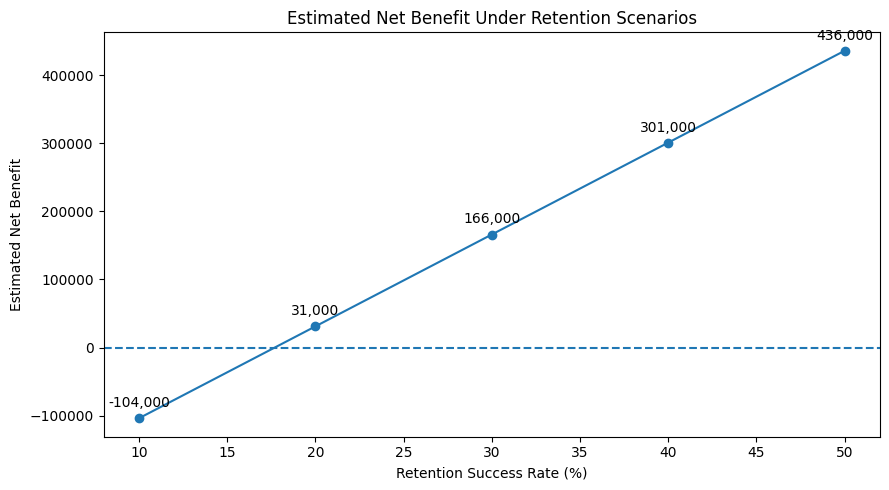

In [97]:
# Prepare scenario data for visualization
scenario_chart = revenue_scenarios[
    [
        "Retention Success Rate",
        "Estimated Net Benefit"
    ]
].copy()

# Convert retention rate to percentage
scenario_chart["Retention Success Rate"] = (
    scenario_chart["Retention Success Rate"] * 100
)

# Create visualization
plt.figure(figsize=(9, 5))

plt.plot(
    scenario_chart["Retention Success Rate"],
    scenario_chart["Estimated Net Benefit"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Retention Success Rate (%)")
plt.ylabel("Estimated Net Benefit")
plt.title("Estimated Net Benefit Under Retention Scenarios")

# Add labels
for x, y in zip(
    scenario_chart["Retention Success Rate"],
    scenario_chart["Estimated Net Benefit"]
):
    plt.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()
plt.show()

## Step 88 — Prepare Dashboard Dataset

The customer risk table will be converted into a dashboard-ready dataset.

The exported dataset contains customer attributes, predicted churn probabilities, risk classifications, and retention flags.

The historical Actual Churn column is retained for model evaluation and dashboard analysis of the test set. In a production prediction system, this outcome would not be available at prediction time.

The resulting CSV will be used as an input to the dashboard.

In [98]:
# Select columns required for the dashboard
dashboard_columns = [
    "CustomerID",
    "Churn Probability",
    "Risk Level",
    "Retention Flag",
    "Contract",
    "Tenure Months",
    "Internet Service",
    "Monthly Charges",
    "Total Charges",
    "Payment Method",
    "Dependents",
    "Online Security",
    "Tech Support",
    "Actual Churn"
]

dashboard_data = customer_risk_table[
    dashboard_columns
].copy()

# Round probability for readability
dashboard_data["Churn Probability"] = (
    dashboard_data["Churn Probability"].round(4)
)

# Save dashboard dataset
dashboard_data.to_csv(
    "../data/customer_churn_predictions.csv",
    index=False
)

print("Dashboard dataset created successfully.")
print(f"Rows: {dashboard_data.shape[0]}")
print(f"Columns: {dashboard_data.shape[1]}")
print("\nSaved to:")
print("../data/customer_churn_predictions.csv")

display(dashboard_data.head(10))

Dashboard dataset created successfully.
Rows: 1409
Columns: 14

Saved to:
../data/customer_churn_predictions.csv


,CustomerID,Churn Probability,Risk Level,Retention Flag,Contract,Tenure Months,Internet Service,Monthly Charges,Total Charges,Payment Method,Dependents,Online Security,Tech Support,Actual Churn
886,5178-LMXOP,0.8834,High Risk,Yes,Month-to-month,1,Fiber optic,95.10,95.10,Electronic check,No,No,No,1
2567,6630-UJZMY,0.8573,High Risk,Yes,Month-to-month,4,Fiber optic,83.25,308.05,Electronic check,No,No,No,0
684,6861-XWTWQ,0.8529,High Risk,Yes,Month-to-month,7,Fiber optic,99.25,665.45,Electronic check,No,No,No,1
1818,0295-PPHDO,0.8445,High Risk,Yes,Month-to-month,1,Fiber optic,95.45,95.45,Electronic check,No,No,No,1
590,7181-BQYBV,0.8395,High Risk,Yes,Month-to-month,1,Fiber optic,102.45,102.45,Electronic check,No,Yes,No,1
1827,1400-MMYXY,0.8377,High Risk,Yes,Month-to-month,3,Fiber optic,105.90,334.65,Electronic check,No,No,No,1
3732,4927-WWOOZ,0.8327,High Risk,Yes,Month-to-month,2,Fiber optic,91.45,171.45,Electronic check,No,No,No,0
1681,8884-ADFVN,0.8320,High Risk,Yes,Month-to-month,7,Fiber optic,101.95,700.85,Electronic check,No,No,No,1
598,7180-PISOG,0.8319,High Risk,Yes,Month-to-month,1,Fiber optic,74.50,74.50,Electronic check,No,No,No,1
4845,8161-QYMTT,0.8296,High Risk,Yes,Month-to-month,7,Fiber optic,94.10,701.30,Electronic check,No,No,No,0


## Step 89 — Dashboard KPI Metrics

Key Performance Indicators (KPIs) provide a high-level summary of the customer churn prediction results.

The dashboard will display:

- Total customers evaluated
- Number of customers classified as high risk
- Percentage of customers classified as high risk
- Average predicted churn probability
- Observed churn rate in the evaluation dataset
- Number of actual churners identified by the model

These metrics summarize the model's customer-risk segmentation before users explore individual customers and business patterns.

In [99]:
# Calculate dashboard KPI metrics

total_customers = len(dashboard_data)

high_risk_customers = (
    dashboard_data["Risk Level"] == "High Risk"
).sum()

high_risk_percentage = (
    high_risk_customers / total_customers
) * 100

average_churn_probability = (
    dashboard_data["Churn Probability"].mean()
) * 100

observed_churn_rate = (
    dashboard_data["Actual Churn"].mean()
) * 100

actual_churners_flagged = (
    (
        (dashboard_data["Risk Level"] == "High Risk") &
        (dashboard_data["Actual Churn"] == 1)
    )
    .sum()
)

# Display KPIs
print(f"Total Customers: {total_customers:,}")
print(f"High-Risk Customers: {high_risk_customers:,}")
print(f"High-Risk Percentage: {high_risk_percentage:.2f}%")
print(f"Average Churn Probability: {average_churn_probability:.2f}%")
print(f"Observed Churn Rate: {observed_churn_rate:.2f}%")
print(f"Actual Churners Flagged: {actual_churners_flagged:,}")

Total Customers: 1,409
High-Risk Customers: 478
High-Risk Percentage: 33.92%
Average Churn Probability: 26.71%
Observed Churn Rate: 26.54%
Actual Churners Flagged: 270


## Step 90 — Build the Streamlit Dashboard

A Streamlit dashboard will be created to communicate the customer churn prediction results to business users.

The first version of the dashboard will:

- Load the exported customer prediction dataset.
- Display key churn KPIs.
- Provide a simple business-facing interface for exploring model results.

Additional visualizations and customer-level analysis will be added in subsequent steps.

In [100]:
import streamlit as st
import pandas as pd


# --------------------------------------------------
# Page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)


# --------------------------------------------------
# Load dashboard dataset
# --------------------------------------------------

DATA_PATH = "../data/customer_churn_predictions.csv"

dashboard_data = pd.read_csv(DATA_PATH)


# --------------------------------------------------
# Calculate KPIs
# --------------------------------------------------

total_customers = len(dashboard_data)

high_risk_customers = (
    dashboard_data["Risk Level"] == "High Risk"
).sum()

high_risk_percentage = (
    high_risk_customers / total_customers
) * 100

average_churn_probability = (
    dashboard_data["Churn Probability"].mean()
) * 100

observed_churn_rate = (
    dashboard_data["Actual Churn"].mean()
) * 100

actual_churners_flagged = (
    (
        (dashboard_data["Risk Level"] == "High Risk") &
        (dashboard_data["Actual Churn"] == 1)
    )
    .sum()
)


# --------------------------------------------------
# Dashboard title
# --------------------------------------------------

st.title("Customer Churn Prediction & Retention Analytics")

st.markdown(
    """
    This dashboard summarizes machine learning-based customer churn
    predictions and highlights customers who may require retention attention.
    """
)


# --------------------------------------------------
# KPI section
# --------------------------------------------------

st.subheader("Key Performance Indicators")

col1, col2, col3, col4, col5 = st.columns(5)

with col1:
    st.metric(
        "Total Customers",
        f"{total_customers:,}"
    )

with col2:
    st.metric(
        "High-Risk Customers",
        f"{high_risk_customers:,}"
    )

with col3:
    st.metric(
        "High-Risk %",
        f"{high_risk_percentage:.2f}%"
    )

with col4:
    st.metric(
        "Avg Churn Probability",
        f"{average_churn_probability:.2f}%"
    )

with col5:
    st.metric(
        "Actual Churners Flagged",
        f"{actual_churners_flagged:,}"
    )


# --------------------------------------------------
# Evaluation note
# --------------------------------------------------

st.info(
    "This dashboard uses the held-out test dataset. "
    "Actual Churn is available here for model evaluation only; "
    "it would not be available when making a real-time prediction."
)

2026-09-19 10:57:37.697 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 10:57:37.738 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 10:57:38.917 
  command:

    streamlit run C:\Users\Reddy\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-19 10:57:38.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 10:57:38.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 10:57:38.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 10:57:38.939 Thread 'MainThread': missing ScriptRunContext! This warning can b

DeltaGenerator()